# Colab Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Thesis/MyThesis

/content/drive/MyDrive/Thesis/MyThesis


# Import Modules

In [3]:
import sys
sys.path.append("sepsisSimDiabetes")
sys.path.append("mrl")

In [4]:
!pip install numpy-indexed

In [5]:
import itertools as it
import os
import numpy as np
import pandas as pd
import pickle as pkl
from tqdm import tqdm_notebook as tqdm
import copy
import numpy_indexed as npi
import matplotlib.pyplot as plt
import random
import gc
from sklearn.metrics import (
    mutual_info_score,
    normalized_mutual_info_score,
)

In [8]:
from sepsisSimDiabetes.State import State
from sepsisSimDiabetes.Action import Action
from sepsisSimDiabetes.MDP import MDP
from sepsisSimDiabetes.DataGenerator import DataGenerator

In [9]:
from mrl.mdp_utils import *
from mrl.testing import *
from mrl.clustering import *
from mrl.model import MDP_model
from mrl.evaluation import *

# Build ground truth P/R; Solve true_pi (Sepsis Simulator)

In [ ]:
# Parameters
n_components = State.NUM_HID_STATES       # 2: non-diabetic / diabetic
n_actions = Action.NUM_ACTIONS_TOTAL      # 8
n_states = State.NUM_OBS_STATES           # 720

sink_idx = n_states                       # 720
n_states_with_sink = n_states + 1         # 721

In [ ]:
# Build R array
# =========================================================
components = [0, 1]
states = range(n_states)
actions = range(n_actions)
dummy_pol = np.ones((n_states, n_actions)) / n_actions

# =========================================================
# Build state-level true reward vector: R[s]
# =========================================================
R_true = np.zeros(n_states_with_sink)

for s_idx in states:
    # set p_diabetes=0/diabetic_idx=0 to initialize
    mdp = MDP(
        init_state_idx=s_idx,
        init_state_idx_type='obs',
        policy_array=dummy_pol,
        policy_idx_type='obs',
        p_diabetes=0
    )

    R_true[s_idx] = mdp.calculateReward()

R_true[sink_idx] = 0

print("R_true shape:", R_true.shape)
print("num death states (-1):", np.sum(R_true == -1))
print("num neutral states (0):", np.sum(R_true == 0))
print("num discharge states (+1):", np.sum(R_true == 1))

R_true shape: (721,)
num death states (-1): 416
num neutral states (0): 304
num discharge states (+1): 1


In [ ]:
# Build P array
# =========================================================
# Repeat each (s, a, diabetic_idx) combination num_mc times
# 500 can be used for debugging first
num_mc = 500

P_true = np.zeros(
    (
        n_actions,
        n_states_with_sink,
        n_states_with_sink
    )
)
dummy_pol = np.ones((n_states, n_actions)) / n_actions


for s_idx in range(n_states):
    # Determine whether the observed state is a terminal death/discharge state.
    # diabetic_idx does not affect check_absorbing_state/calculateReward
    state_check = State(
        state_idx=s_idx,
        idx_type="obs",
        diabetic_idx=0
    )

    is_terminal = state_check.check_absorbing_state()

    # terminal states -> sink
    if is_terminal:
        for a_idx in range(n_actions):
            P_true[
                a_idx,
                s_idx,
                sink_idx
            ] = 1.0

        continue

    # non-terminal states -> estimate transition by Monte Carlo
    for a_idx in range(n_actions):
        action = Action(action_idx=a_idx)
        next_probs = np.zeros(n_states_with_sink)
        # obs state transition depends on hidden diabetic_idx
        # estimate conditional transitions for diabetic_idx = 0 and 1,
        # then mix using p_diabetes
        for diabetic_idx, weight in [(0, 0.8), (1, 0.2)]:
            mdp = MDP(
                init_state_idx=s_idx,
                init_state_idx_type="obs",
                policy_array=dummy_pol,
                policy_idx_type="obs",
                p_diabetes=0.2
            )

            component_counts = np.zeros(n_states_with_sink)

            for _ in range(num_mc):

                # reset state before every one-step query
                mdp.state = State(
                    state_idx=s_idx,
                    idx_type="obs",
                    diabetic_idx=diabetic_idx
                )

                reward = mdp.transition(action)

                next_s_idx = int(
                    mdp.state.get_state_idx(
                        idx_type="obs"
                    )
                )

                component_counts[next_s_idx] += 1

            component_probs = component_counts / component_counts.sum()

            next_probs += weight * component_probs

        P_true[
            a_idx,
            s_idx,
            :
        ] = next_probs


# sink -> sink
for a_idx in range(n_actions):
    P_true[
        a_idx,
        sink_idx,
        sink_idx
    ] = 1.0


print("P_true shape:", P_true.shape)

row_sums = P_true.sum(axis=2)
bad_rows = np.where(
    ~np.isclose(row_sums, 1.0)
)
print("bad rows:", bad_rows)
print("num bad rows:", len(bad_rows[0]))

P_true shape: (8, 721, 721)
min row sum: 0.9999999999999998
max row sum: 1.0000000000000004
bad rows: (array([], dtype=int64), array([], dtype=int64))
num bad rows: 0


In [ ]:
# Solve true_v, true_pi
# =========================================================
true_v, true_pi = SolveMDP(P_true, R_true, prob="max", gamma=1, epsilon=1e-8)

print(true_v)
print(true_pi.shape)
print(true_pi)

[-1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
  2.48702251e-01  2.64880007e-01  2.53646063e-01  2.67444114e-01
  1.88004029e-01  1.91746

In [10]:
# Cache & Reload true_v, true_pi
# =========================================================
cache_dir = "./cache"
os.makedirs(cache_dir, exist_ok=True)

cache_file = os.path.join(cache_dir, "true_policy_gamma1.npz")

if os.path.exists(cache_file):
    data = np.load(cache_file)
    true_v = data["true_v"]
    true_pi = data["true_pi"]
    print("Loaded cached true_v / true_pi")
else:
    true_v, true_pi = SolveMDP(
        P_true,
        R_true,
        prob="max",
        gamma=1,
        epsilon=1e-8,
    )

    np.savez(
        cache_file,
        true_v=true_v,
        true_pi=true_pi,
    )

    print("Computed and cached true_v / true_pi")

Loaded cached true_v / true_pi


# Model Fit

## Genrate Trajectories D (Sepsis Simulator)

In [ ]:
# Build DataGenerator policies
# =========================================================
# policy shape (n_states, n_actions)
n_states = State.NUM_OBS_STATES          # 720
n_actions = Action.NUM_ACTIONS_TOTAL     # 8

num_trajectories = 3000
max_num_steps = 20
p_diabetes = 0.2

# 1. random policy
random_policy = np.ones((n_states, n_actions)) / n_actions

# 2. true optimal policy without sink node
true_pi_dg = true_pi[:-1]

opt_true_policy = np.zeros((n_states, n_actions))
for s in range(n_states):
    opt_true_policy[s, true_pi_dg[s]] = 1

# 3. epsilon greedy policy without sink node
epsilon = 0.5
eps_greedy_policy = np.ones((n_states, n_actions)) * (epsilon / n_actions)
for s in range(n_states):
    eps_greedy_policy[
        s,
        int(true_pi_dg[s])
    ] += 1.0 - epsilon

# asserts
assert random_policy.shape == (n_states, n_actions)
assert np.allclose(random_policy.sum(axis=1), 1.0)

assert opt_true_policy.shape == (n_states, n_actions)
assert np.allclose(opt_true_policy.sum(axis=1), 1.0)

assert eps_greedy_policy.shape == (n_states, n_actions)
assert np.allclose(eps_greedy_policy.sum(axis=1), 1.0)

In [ ]:
# Sample D from Sepsis Simulator
# =========================================================
dg = DataGenerator()

iter_states, iter_actions, iter_lengths, iter_rewards, iter_component, emp_tx_mat, emp_r_mat = dg.simulate(
    num_iters=num_trajectories,
    max_num_steps=max_num_steps,
    policy=random_policy,
    policy_idx_type='obs',
    p_diabetes=p_diabetes,
    output_state_idx_type='obs',
    use_tqdm=True,
    tqdm_desc='Generating trajectories'
)

Generating trajectories:   0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
# 查看输出结果的形状
print("iter_states shape:", iter_states.shape)
print("iter_actions shape:", iter_actions.shape)
print("iter_lengths shape:", iter_lengths.shape)
print("iter_rewards shape:", iter_rewards.shape)
print("iter_component shape:", iter_component.shape)
print("emp_tx_mat shape:", emp_tx_mat.shape)
print("emp_r_mat shape:", emp_r_mat.shape)

# 查看第 0 条轨迹
traj_id = 0
length = int(iter_lengths[traj_id, 0])

print("\n=== Trajectory 0 ===")
print("diabetic component:", int(iter_component[traj_id, 0, 0]))
print("length:", length)
print("states:", iter_states[traj_id, :length+1, 0])
print("actions:", iter_actions[traj_id, :length+1, 0])
print("rewards:", iter_rewards[traj_id, :length+1, 0])

# 统计Terminal Reward结果 （reward 只在终止步非零，所以对每条轨迹按时间求和）
terminal_rewards = iter_rewards.sum(axis=1).flatten()

print("\n=== Terminal reward summary ===")
print("num +1 terminal:", np.sum(terminal_rewards == 1))
print("num -1 terminal:", np.sum(terminal_rewards == -1))
print("num zero terminal (not ended within max_num_steps):", np.sum(terminal_rewards == 0))

## FQI Baseline Fit

In [ ]:
# Generate long df of sample D
df_scheme_b = dg_to_df_fqi(
    iter_states=iter_states,
    iter_actions=iter_actions,
    iter_lengths=iter_lengths,
    iter_rewards=iter_rewards
)


df_scheme_b.head(50)

,ID,State,Action,Reward,NextState
0,0,296,4,0.0,292
1,0,292,4,0.0,292
2,0,292,4,0.0,292
3,0,292,3,0.0,371
4,0,371,4,0.0,372
5,0,372,0,0.0,328
6,0,328,6,0.0,373
7,0,373,5,0.0,454
8,0,454,4,0.0,452
9,0,452,7,0.0,455


In [ ]:
# Run Tabular FQI
nS=720
nA=8
G_min=-40

Qs_b = run_tabular_FQI(
    df_data=df_scheme_b,
    gamma=0.99,
    n_epochs=100,
    nS=nS,
    nA=nA,
    G_min=G_min,
    use_tqdm=True
)

# Final Q table
Q_b = Qs_b[-1]

print("Q_b shape:", Q_b.shape)

# Greedy policy from final Q
pi_fqi_b = np.argmax(Q_b, axis=1)

print("pi_fqi_b shape:", pi_fqi_b.shape)
print("first 30 actions:", pi_fqi_b[:30])

# action distribution
print("action counts:")
print(np.bincount(pi_fqi_b, minlength=nA))

# convert to DataGenerator-compatible policy array
fqi_policy_b = np.zeros((nS, nA))

for s in range(nS):
    fqi_policy_b[s, int(pi_fqi_b[s])] = 1.0

print("policy row sums:", fqi_policy_b.sum(axis=1).min(), fqi_policy_b.sum(axis=1).max())

100%|██████████| 100/100 [00:01<00:00, 56.93it/s]

Q_b shape: (720, 8)
pi_fqi_b shape: (720,)
first 30 actions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
action counts:
[460   8  58  32  51  28  56  27]
policy row sums: 1.0 1.0


In [ ]:
print(Q_b.min())
print(Q_b.max())
print(Q_b.mean())

## MRL Model Fit

### MRL model training (debug)

In [ ]:
# Generate long df of sample D
df_scheme_a = dg_to_df_mrl(
    iter_states=iter_states,
    iter_actions=iter_actions,
    iter_lengths=iter_lengths,
    iter_rewards=iter_rewards,
    iter_component=iter_component
)


df_scheme_a.head(50)

copied data
initializing clusters...
Clusters Initialized



Splitting...:   0%|          | 0/97 [00:00<?, ?it/s]
Splitting... |#Clusters:3:   0%|          | 0/97 [00:00<?, ?it/s]


[findContradictionStochastic]
rows: 29481
clusters: 3
actions: 9
groups: 10
max std: 696.8866532791696
threshold: 0
will stop: False
chosen: (np.int64(0), 1)

[timing seconds]
groupby_apply_total: 0.1027
slice: 0.0044
encode: 0.0119
fit: 0.052
predict: 0.0146
score: 0.0032
total: 0.1383

[group info]
groups: 10
single_class_groups: 2
multi_class_groups: 8

[ITER 0]
[time] find contradiction: 0.1391s
[chosen] c=0, a=1
[clusters before] actual=3, nc=3


Splitting... |#Clusters:24:  22%|██▏       | 21/97 [3:46:24<13:39:23, 646.89s/it]


[time] splitStochastic: 0.0511s
[clusters after] actual=4, nc=3
[split success] True
[old cluster 0] before=27347, after=26074
[new cluster 3] size=1273


...

max std: 6.930043395761558
threshold: 0
will stop: False
chosen: (np.int64(67), 0)

[timing seconds]
groupby_apply_total: 2.5416
slice: 0.1692
encode: 0.1257
fit: 1.3848
predict: 0.7029
score: 0.0658
total: 2.5622

[group info]
groups: 770
single_class_groups: 39
multi_class_groups: 731

[ITER 96]
[time] find contradiction: 2.5634s
[chosen] c=67, a=0
[clusters before] actual=99, nc=99
[time] splitStochastic: 0.0192s
[clusters after] actual=99, nc=99
[split success] False
[old cluster 67] before=296, after=296
[new cluster 99] size=0
[skip] split failed; pair (67, 0) cooldown=3; nc unchanged; no training error recorded
------------------------------------------------------------

[findContradictionStochastic]
rows: 29439
clusters: 99
actions: 9
groups: 770



Splitting... |#Clusters:99:  99%|█████████▉| 96/97 [06:01<00:09,  9.04s/it]

max std: 7.372279928446943
threshold: 0
will stop: False
chosen: (np.int64(79), 1)

[timing seconds]
groupby_apply_total: 2.5014
slice: 0.1633
encode: 0.1224
fit: 1.3743
predict: 0.6947
score: 0.0646
total: 2.5146

[group info]
groups: 770
single_class_groups: 39
multi_class_groups: 731

[ITER 96]
[time] find contradiction: 2.5153s
[chosen] c=79, a=1
[clusters before] actual=99, nc=99
[time] splitStochastic: 0.0206s
[clusters after] actual=99, nc=99
[split success] False
[old cluster 79] before=255, after=255
[new cluster 99] size=0
[skip] split failed; pair (79, 1) cooldown=3; nc unchanged; no training error recorded
------------------------------------------------------------

[findContradictionStochastic]
rows: 29398
clusters: 99
actions: 9
groups: 769
max std: 6.75597418187463
threshold: 0
will stop: False
chosen: (np.int64(79), 3)

[timing seconds]
groupby_apply_total: 2.472
slice: 0.1607
encode: 0.123
fit: 1.3559
predict: 0.6884
score: 0.0632
total: 2.4881

[group info]
groups: 7


Splitting... |#Clusters:99: 100%|██████████| 97/97 [06:06<00:00,  3.78s/it]

[time] training_value_error: 2.2614s
[train error] 0.8267305082875153
[time] iteration total: 5.0492s
[time] unaccounted other: 0.2750s
------------------------------------------------------------
Cooldown added: 12
Cooldown recovered: 2
Cooldown expired: 11


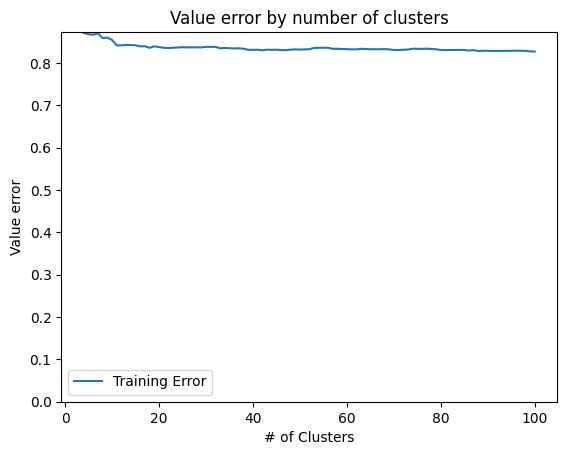

In [ ]:
# Setting parameters for model fitting
max_k = 100
pfeatures = 7
classification = 'DecisionTreeClassifier'
split_classifier_params = {'random_state':0, 'max_depth':2}
clustering = 'Agglomerative'
n_clusters = None
distance_threshold = 0.5 #for Agglomerative clustering
random_state = 0
h = -1
gamma = 1
cv = 5
th = 0
eta = 25
precision_thresh = 1e-14

m = MDP_model()
m.fit(df_scheme_a, # df: dataframe in the format ['ID', 'TIME', ...features..., 'RISK', 'ACTION']
    pfeatures, # int: number of features
    h, # int: time horizon (# of actions we want to optimize)
    gamma, # discount factor
    max_k, # int: number of iterations
    distance_threshold, # clustering diameter for Agglomerative clustering
    cv, # number for cross validation
    th, # splitting threshold
    eta, # incoherence threshold, calculated by eta*sqrt(datapoints)/clusters
    precision_thresh, # precision threshold
    classification, # classification method
    split_classifier_params, # classifier params
    clustering,# clustering method from Agglomerative, KMeans, and Birch
    n_clusters, # number of clusters for KMeans
    random_state,
    stochastic=True,
    plot=True)

In [ ]:
m.df_trained.head(50)

,ID,TIME,FEATURE_0,FEATURE_1,FEATURE_2,FEATURE_3,FEATURE_4,FEATURE_5,FEATURE_6,ACTION,RISK,CLUSTER,NEXT_CLUSTER
0,0,0,2,1,1,3,0,0,0,2,0.0,85,57
1,0,1,2,1,1,2,0,0,1,7,0.0,57,51
2,0,2,1,2,1,2,1,1,1,4,0.0,51,3
3,0,3,1,1,0,1,1,0,0,0,0.0,3,8
4,0,4,1,2,0,2,0,0,0,4,0.0,8,38
5,0,5,1,1,0,3,1,0,0,6,0.0,38,43
6,0,6,1,1,1,2,1,0,1,5,0.0,43,0
7,0,7,1,2,1,2,1,1,0,3,0.0,0,64
8,0,8,1,2,1,2,0,1,1,6,0.0,64,27
9,0,9,1,1,1,1,1,0,1,6,0.0,27,96


In [ ]:
print("Effective clusters:", m.df_trained["CLUSTER"].nunique())
print("Cluster labels:", sorted(m.df_trained["CLUSTER"].unique()))
print("Max cluster label:", m.df_trained["CLUSTER"].max())
print("Best K:", m.opt_k)
print("Next Cluster labels:", sorted(m.df_trained["NEXT_CLUSTER"].unique()))

In [ ]:
P_df, R_df = get_MDP_stochastic(m.df_trained)

print(P_df.shape)
print(R_df.shape)

In [ ]:
P_df0 = (
    P_df.sort_values(
        ["CLUSTER", "ACTION", "NEXT_CLUSTER"],
        ascending=[True, True, True]
    )
    .set_index(
        ["CLUSTER", "ACTION", "NEXT_CLUSTER"]
    )
)
P_df0.tail(20)

### Solve MDP

In [ ]:
m.solve_MDP(
    alpha=0.2,
    beta=0.8,
    min_action_obs=-1,
    min_action_purity=0.7,
    prob="max",
    gamma=0.99,
    epsilon=1e-8,
    p=True  # print the results
)

optimal_values = m.v      # 每个状态的最优价值
optimal_policy = m.pi     # 每个状态的最优策略

print("\n" + "="*60)
print("最优MDP求解结果")
print("="*60)
print(f"\n最优价值函数 V: {optimal_values}")
print(f"最优策略 pi: {optimal_policy}")

# Performance Evaluation as a Function of Data Size

## Optimality Gap

### Generate Trajectories D_evaluation

In [8]:
# Sample D from Sepsis Simulator
# =========================================================
num_trajectories = 3000
max_num_steps = 20
p_diabetes = 0.2
n_states = State.NUM_OBS_STATES          # 720
n_actions = Action.NUM_ACTIONS_TOTAL     # 8

random_policy = np.ones((n_states, n_actions)) / n_actions

dg = DataGenerator()

iter_states, iter_actions, iter_lengths, iter_rewards, iter_component, emp_tx_mat, emp_r_mat = dg.simulate(
    num_iters=num_trajectories,
    max_num_steps=max_num_steps,
    policy=random_policy,
    policy_idx_type='obs',
    p_diabetes=p_diabetes,
    output_state_idx_type='obs',
    use_tqdm=True,
    tqdm_desc='Generating trajectories'
)

# 查看输出结果的形状
print("iter_states shape:", iter_states.shape)
print("iter_actions shape:", iter_actions.shape)
print("iter_lengths shape:", iter_lengths.shape)
print("iter_rewards shape:", iter_rewards.shape)
print("iter_component shape:", iter_component.shape)
print("emp_tx_mat shape:", emp_tx_mat.shape)
print("emp_r_mat shape:", emp_r_mat.shape)

# 查看第 0 条轨迹
traj_id = 0
length = int(iter_lengths[traj_id, 0])

print("\n=== Trajectory 0 ===")
print("diabetic component:", int(iter_component[traj_id, 0, 0]))
print("length:", length)
print("states:", iter_states[traj_id, :length+1, 0])
print("actions:", iter_actions[traj_id, :length, 0])
print("rewards:", iter_rewards[traj_id, :length+1, 0])

# 统计Terminal Reward结果 （reward 只在终止步非零，所以对每条轨迹按时间求和）
terminal_rewards = iter_rewards.sum(axis=1).flatten()

print("\n=== Terminal reward summary ===")
print("num +1 terminal:", np.sum(terminal_rewards == 1))
print("num -1 terminal:", np.sum(terminal_rewards == -1))
print("num zero terminal (not ended within max_num_steps):", np.sum(terminal_rewards == 0))

Generating trajectories:   0%|          | 0/3000 [00:00<?, ?it/s]

iter_states shape: (3000, 21, 1)
iter_actions shape: (3000, 21, 1)
iter_lengths shape: (3000, 1)
iter_rewards shape: (3000, 21, 1)
iter_component shape: (3000, 21, 1)
emp_tx_mat shape: (8, 720, 720)
emp_r_mat shape: (8, 720, 720)

=== Trajectory 0 ===
diabetic component: 0
length: 2
states: [136 140  88]
actions: [4 0]
rewards: [ 0.  0. -1.]

=== Terminal reward summary ===
num +1 terminal: 159
num -1 terminal: 2422
num zero terminal (not ended within max_num_steps): 419


In [9]:
# Dataframe for MRL
# =========================================================
df = dg_to_df_mrl(
    iter_states=iter_states,
    iter_actions=iter_actions,
    iter_lengths=iter_lengths,
    iter_rewards=iter_rewards,
    iter_component=iter_component
)


df.head(20)

,ID,TIME,FEATURE_0,FEATURE_1,FEATURE_2,FEATURE_3,FEATURE_4,FEATURE_5,FEATURE_6,ACTION,RISK
0,0,0,0,1,1,2,0,0,0,4,0.0
1,0,1,0,1,1,2,1,0,0,0,0.0
2,0,2,0,1,0,1,0,0,0,None,-1.0
3,1,0,0,2,1,2,0,0,0,1,0.0
4,1,1,0,2,1,2,0,1,0,2,0.0
5,1,2,0,2,1,2,0,0,1,2,0.0
6,1,3,0,2,1,2,0,0,1,5,0.0
7,1,4,0,2,1,2,1,1,0,2,0.0
8,1,5,0,2,1,1,0,0,1,None,-1.0
9,2,0,1,0,0,2,0,0,0,6,0.0


In [10]:
# Dataframe for FQI baseline
# =========================================================
df_b = dg_to_df_fqi(
    iter_states=iter_states,
    iter_actions=iter_actions,
    iter_lengths=iter_lengths,
    iter_rewards=iter_rewards
)

In [12]:
# 检查 s 覆盖率
# =========================================================
state_cols = [
    "FEATURE_0",
    "FEATURE_1",
    "FEATURE_2",
    "FEATURE_3",
    "FEATURE_4",
    "FEATURE_5",
    "FEATURE_6",
]

n_states_observed = (
    df[state_cols]
    .drop_duplicates()
    .shape[0]
)

print(n_states_observed)

493


In [ ]:
# 检查 sa 覆盖率
# =========================================================
n_sa_observed = (
    df[
        state_cols + ["ACTION"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(n_sa_observed)

2143


### FQI

true policy:   0%|          | 0/5000 [00:00<?, ?it/s]


=== FQI N=100 ===


100%|██████████| 100/100 [00:00<00:00, 1802.08it/s]


FQI N=100:   0%|          | 0/5000 [00:00<?, ?it/s]

V_true: 0.19530374448549517
V_fqi: -0.4691656245779781
gap: 0.6644693690634733

=== FQI N=200 ===


...

FQI N=500:   0%|          | 0/5000 [00:00<?, ?it/s]

V_true: 0.19530374448549517
V_fqi: -0.4186136833989567
gap: 0.6139174278844519

=== FQI N=1000 ===


100%|██████████| 100/100 [00:00<00:00, 151.77it/s]


FQI N=1000:   0%|          | 0/5000 [00:00<?, ?it/s]

V_true: 0.19530374448549517
V_fqi: -0.21493014719041612
gap: 0.4102338916759113


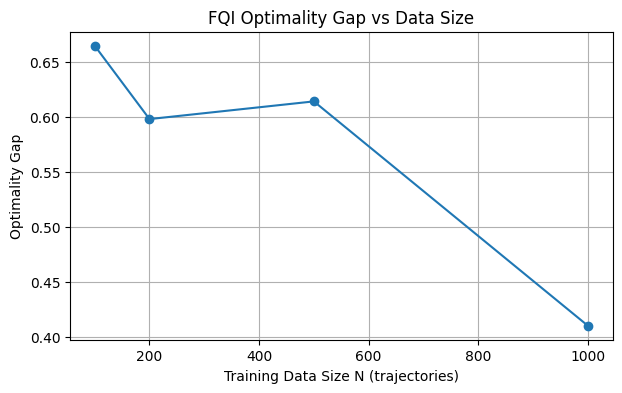

In [ ]:
nS = State.NUM_OBS_STATES
nA = Action.NUM_ACTIONS_TOTAL
gamma = 0.99
G_min = -40

Ns = [100, 200, 500, 1000]
# Ns = [100, 300, 500, 1000, 1500, 2000, 2500, 3000]

# true policy
true_pi_dg = true_pi[:720]
true_policy_array = deterministic_pi_to_prob_array(
    true_pi_dg,
    num_actions=nA,
)

# evaluate true policy once
V_true, true_returns = estimate_policy_value(
    policy_array=true_policy_array,
    num_iters=5000,
    max_num_steps=20,
    gamma=gamma,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=0.2,
    use_tqdm=True,
    tqdm_desc="true policy",
)

fqi_values = []
fqi_gaps = []
fqi_policies = []
fqi_Qs = []

for N in Ns:
    print(f"\n=== FQI N={N} ===")

    df_N = df_b[
        df_b["ID"] < N
    ].copy()

    Qs_N = run_tabular_FQI(
        df_data=df_N,
        gamma=gamma,
        n_epochs=100,
        nS=nS,
        nA=nA,
        G_min=G_min,
        use_tqdm=True,
    )

    Q_N = Qs_N[-1]
    pi_fqi_N = np.argmax(Q_N, axis=1)

    fqi_policy_N = np.zeros((nS, nA))
    for s in range(nS):
        fqi_policy_N[s, int(pi_fqi_N[s])] = 1.0

    V_fqi_N, returns_fqi_N = estimate_policy_value(
        policy_array=fqi_policy_N,
        num_iters=5000,
        max_num_steps=20,
        gamma=gamma,
        policy_idx_type="obs",
        output_state_idx_type="obs",
        p_diabetes=0.2,
        use_tqdm=True,
        tqdm_desc=f"FQI N={N}",
    )

    gap_N = abs(V_true - V_fqi_N)

    fqi_values.append(V_fqi_N)
    fqi_gaps.append(gap_N)
    fqi_policies.append(pi_fqi_N)
    fqi_Qs.append(Q_N)

    print("V_true:", V_true)
    print("V_fqi:", V_fqi_N)
    print("gap:", gap_N)


plt.figure(figsize=(7, 4))
plt.plot(Ns, fqi_gaps, marker="o")
plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Optimality Gap")
plt.title("FQI Optimality Gap vs Data Size")
plt.grid(True)
plt.show()

### MRL

Trajectories: 100
Transitions: 1042
Mean trajectory length: 10.42
Action counts:
ACTION
3       141
7       127
4       125
0       118
2       116
6       115
1       113
5        99
None     88
Name: count, dtype: int64
Reward counts:
RISK
 0.0    954
-1.0     79
 1.0      9
Name: count, dtype: int64
Training for N= 100  .....
copied data
initializing clusters...
Clusters Initialized
      ID  TIME  FEATURE_0  FEATURE_1  FEATURE_2  FEATURE_3  FEATURE_4  \
0      0     0          1          0          1          1          0   
1      0     1          1          1          1          1          1   
2      0     2          1          1          1          1          1   
3      0     3          1          2          1          1          1   
4      0     4          1          2          1          1          0   
...   ..   ...        ...        ...        ...        ...        ...   
1037  99     1          1          0          1          1          1   
1038  99     2          1  

Splitting... |#Clusters:3:   0%|          | 0/197 [00:00<?, ?it/s]

Finding contradiction...
max std: 39.38908478246227
historical max std: 39.38908478246227
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(1))
Found contradiction in 0.07793784141540527!


Splitting... |#Clusters:4:   1%|          | 1/197 [00:00<01:25,  2.28it/s]

Cluster splitted 0 | Action causing contradiction: 1
Split Success
Split clusters in 0.011388063430786133!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.8899438184514796
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8899438184514796
Saving best model...
train error:  0.8899438184514796
new opt_k 4
Model saved in 0.00020813941955566406
Finding contradiction...
max std: 45.11866499575197
historical max std: 45.11866499575197
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(3), np.int64(3))
Found contradiction in 0.061841726303100586!


...

Cluster splitted 6 | Action causing contradiction: 0
Split Success
Split clusters in 0.010126352310180664!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.7489993324429602
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.7489993324429602
Saving best model...
train error:  0.7489993324429602
Model saved in 1.5974044799804688e-05
Finding contradiction...
max std: 2.269693845669907
historical max std: 45.11866499575197
relative max std: 0.05030498676952441
relative threshold: 0.05
will stop: False
chosen: (np.int64(26), np.int64(0))
Found contradiction in 0.3799781799316406!


Splitting... |#Clusters:49:  23%|██▎       | 46/197 [00:24<01:33,  1.61it/s]

Cluster splitted 26 | Action causing contradiction: 0
Split Success
Split clusters in 0.01052713394165039!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.7539893898457724
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.7539893898457724
Saving best model...
train error:  0.7539893898457724
Model saved in 1.621246337890625e-05
Finding contradiction...


Splitting... |#Clusters:49:  23%|██▎       | 46/197 [00:25<01:22,  1.83it/s]

max std: 2.2275096969986246
historical max std: 45.11866499575197
relative max std: 0.0493700267330239
relative threshold: 0.05
will stop: True
chosen: (-1, -1)
Found contradiction in 0.3728916645050049!


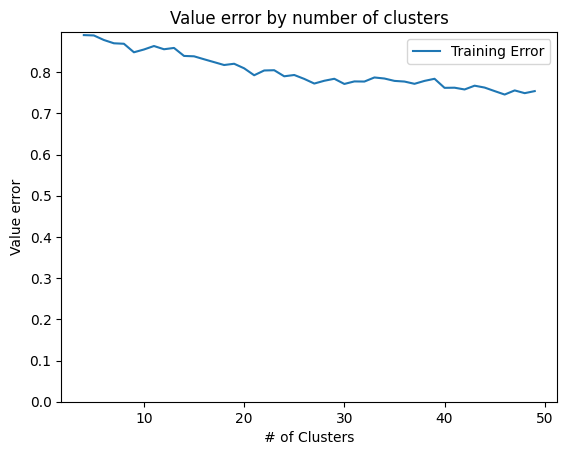

Trajectories: 200
Transitions: 2027
Mean trajectory length: 10.135
Action counts:
ACTION
7       258
3       251
0       237
4       227
6       223
1       222
2       221
5       213
None    175
Name: count, dtype: int64
Reward counts:
RISK
 0.0    1852
-1.0     164
 1.0      11
Name: count, dtype: int64
Training for N= 200  .....
copied data
initializing clusters...
Clusters Initialized
       ID  TIME  FEATURE_0  FEATURE_1  FEATURE_2  FEATURE_3  FEATURE_4  \
0       0     0          1          0          1          1          0   
1       0     1          1          1          1          1          1   
2       0     2          1          1          1          1          1   
3       0     3          1          2          1          1          1   
4       0     4          1          2          1          1          0   
...   ...   ...        ...        ...        ...        ...        ...   
2022  199     8          0          1          1          2          0   
2023  199     9

Splitting... |#Clusters:3:   0%|          | 0/197 [00:00<?, ?it/s]

Finding contradiction...
max std: 68.42033949888625
historical max std: 68.42033949888625
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(1))
Found contradiction in 0.03664660453796387!
Cluster splitted 0 | Action causing contradiction: 1
Split Success
Split clusters in 0.008947134017944336!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.8501470461043783
Calculating training accuracy (grid only) ...
Testing...


Splitting... |#Clusters:4:   1%|          | 1/197 [00:00<00:52,  3.76it/s]

training value error: 0.8501470461043783
Saving best model...
train error:  0.8501470461043783
new opt_k 4
Model saved in 0.0003132820129394531
Finding contradiction...
max std: 63.422870236592516
historical max std: 68.42033949888625
relative max std: 0.9269593033461185
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(1))
Found contradiction in 0.04784703254699707!
Cluster splitted 0 | Action causing contradiction: 1
Split Success
Split clusters in 0.008945226669311523!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.855716074407861
Calculating training accuracy (grid only) ...
Testing...


...

training value error: 0.7875595215601168
Saving best model...
train error:  0.7875595215601168
new opt_k 50
Model saved in 0.0003578662872314453
Finding contradiction...
max std: 3.430165426427562
historical max std: 68.42033949888625
relative max std: 0.05013370953067835
relative threshold: 0.05
will stop: False
chosen: (np.int64(11), np.int64(4))
Found contradiction in 0.5386037826538086!
Cluster splitted 11 | Action causing contradiction: 4
Split Success
Split clusters in 0.008106708526611328!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...
Training Error 0.7858116822750856
Calculating training accuracy (grid only) ...
Testing...


Splitting... |#Clusters:51:  24%|██▍       | 48/197 [00:31<02:02,  1.21it/s]

training value error: 0.7858116822750856
Saving best model...
train error:  0.7858116822750856
new opt_k 51
Model saved in 0.00048804283142089844
Finding contradiction...


Splitting... |#Clusters:51:  24%|██▍       | 48/197 [00:32<01:40,  1.49it/s]

max std: 3.368524681515174
historical max std: 68.42033949888625
relative max std: 0.04923279694585565
relative threshold: 0.05
will stop: True
chosen: (-1, -1)
Found contradiction in 0.5542261600494385!


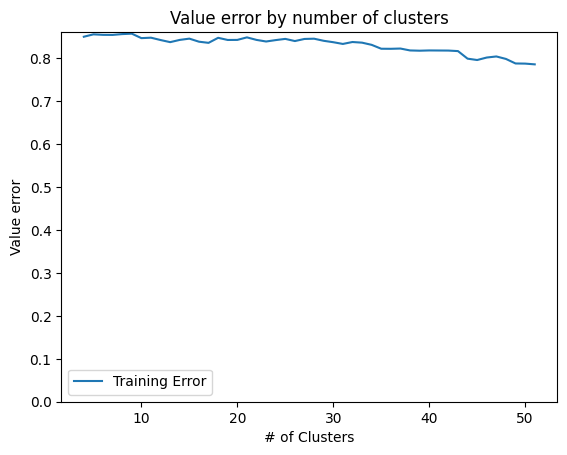

Trajectories: 500
Transitions: 4968
Mean trajectory length: 9.936
Action counts:
ACTION
3       590
7       586
2       574
0       574
6       572
1       563
4       549
5       528
None    432
Name: count, dtype: int64
Reward counts:
RISK
 0.0    4536
-1.0     404
 1.0      28
Name: count, dtype: int64
Training for N= 500  .....
copied data
initializing clusters...
Clusters Initialized
       ID  TIME  FEATURE_0  FEATURE_1  FEATURE_2  FEATURE_3  FEATURE_4  \
0       0     0          1          0          1          1          0   
1       0     1          1          1          1          1          1   
2       0     2          1          1          1          1          1   
3       0     3          1          2          1          1          1   
4       0     4          1          2          1          1          0   
...   ...   ...        ...        ...        ...        ...        ...   
4963  499     2          1          2          1          3          0   
4964  499     3 

Splitting... |#Clusters:3:   0%|          | 0/197 [00:00<?, ?it/s]

Finding contradiction...
max std: 147.4540137257583
historical max std: 147.4540137257583
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(1))
Found contradiction in 0.04174351692199707!
Cluster splitted 0 | Action causing contradiction: 1
Split Success
Split clusters in 0.01166677474975586!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


Splitting... |#Clusters:4:   1%|          | 1/197 [00:00<01:08,  2.87it/s]

Training Error 0.8589528508596965
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8589528508596965
Saving best model...
train error:  0.8589528508596965
new opt_k 4
Model saved in 0.0003261566162109375
Finding contradiction...
max std: 170.48773334831827
historical max std: 170.48773334831827
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(3))
Found contradiction in 0.060073137283325195!
Cluster splitted 0 | Action causing contradiction: 3
Split Success
Split clusters in 0.010942220687866211!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


...

Training Error 0.8337265738837883
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8337265738837883
Saving best model...
train error:  0.8337265738837883
Model saved in 1.2874603271484375e-05
Finding contradiction...
max std: 8.573187498960996
historical max std: 170.48773334831827
relative max std: 0.0502862424796591
relative threshold: 0.05
will stop: False
chosen: (np.int64(29), np.int64(1))
Found contradiction in 0.6058688163757324!
Cluster splitted 29 | Action causing contradiction: 1
Split Success
Split clusters in 0.010709762573242188!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


Splitting... |#Clusters:38:  18%|█▊        | 35/197 [00:26<02:38,  1.02it/s]

Training Error 0.833486652562595
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.833486652562595
Saving best model...
train error:  0.833486652562595
Model saved in 1.3589859008789062e-05
Finding contradiction...


Splitting... |#Clusters:38:  18%|█▊        | 35/197 [00:26<02:03,  1.31it/s]

max std: 8.33843883110565
historical max std: 170.48773334831827
relative max std: 0.04890931838520981
relative threshold: 0.05
will stop: True
chosen: (-1, -1)
Found contradiction in 0.5935561656951904!


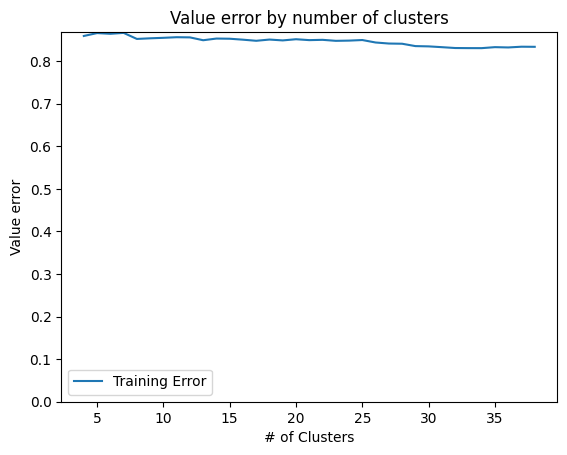

Trajectories: 1000
Transitions: 9744
Mean trajectory length: 9.744
Action counts:
ACTION
7       1166
3       1120
6       1112
2       1110
5       1109
4       1105
0       1100
1       1050
None     872
Name: count, dtype: int64
Reward counts:
RISK
 0.0    8872
-1.0     805
 1.0      67
Name: count, dtype: int64
Training for N= 1000  .....
copied data
initializing clusters...
Clusters Initialized
       ID  TIME  FEATURE_0  FEATURE_1  FEATURE_2  FEATURE_3  FEATURE_4  \
0       0     0          1          0          1          1          0   
1       0     1          1          1          1          1          1   
2       0     2          1          1          1          1          1   
3       0     3          1          2          1          1          1   
4       0     4          1          2          1          1          0   
...   ...   ...        ...        ...        ...        ...        ...   
9739  998    10          2          1          1          1          0   
9740 

Splitting... |#Clusters:3:   0%|          | 0/197 [00:00<?, ?it/s]

Finding contradiction...
max std: 243.73616369191055
historical max std: 243.73616369191055
relative max std: 1.0
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(3))
Found contradiction in 0.056493282318115234!
Cluster splitted 0 | Action causing contradiction: 3
Split Success
Split clusters in 0.014866113662719727!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


Splitting... |#Clusters:4:   1%|          | 1/197 [00:00<01:35,  2.06it/s]

Training Error 0.8773824707617539
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8773824707617539
Saving best model...
train error:  0.8773824707617539
new opt_k 4
Model saved in 0.0004229545593261719
Finding contradiction...
max std: 217.6746339100439
historical max std: 243.73616369191055
relative max std: 0.8930748339224327
relative threshold: 0.05
will stop: False
chosen: (np.int64(0), np.int64(2))
Found contradiction in 0.06617569923400879!
Cluster splitted 0 | Action causing contradiction: 2
Split Success
Split clusters in 0.014962911605834961!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


...

Training Error 0.8384211352297841
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8384211352297841
Saving best model...
train error:  0.8384211352297841
new opt_k 38
Model saved in 0.0005180835723876953
Finding contradiction...
max std: 12.302194906140844
historical max std: 243.73616369191055
relative max std: 0.050473408294434176
relative threshold: 0.05
will stop: False
chosen: (np.int64(18), np.int64(4))
Found contradiction in 0.6113486289978027!
Cluster splitted 18 | Action causing contradiction: 4
Split Success
Split clusters in 0.010688543319702148!
Calculating Incoherences...
Calculating Evaluation Metrics...
Calculating R2 metric...
Calculating training error...


Splitting... |#Clusters:39:  18%|█▊        | 36/197 [00:32<02:55,  1.09s/it]

Training Error 0.8411301920630361
Calculating training accuracy (grid only) ...
Testing...
training value error: 0.8411301920630361
Saving best model...
train error:  0.8411301920630361
Model saved in 1.3113021850585938e-05
Finding contradiction...


Splitting... |#Clusters:39:  18%|█▊        | 36/197 [00:33<02:30,  1.07it/s]

max std: 11.859800769035662
historical max std: 243.73616369191055
relative max std: 0.04865835495805533
relative threshold: 0.05
will stop: True
chosen: (-1, -1)
Found contradiction in 0.6240921020507812!


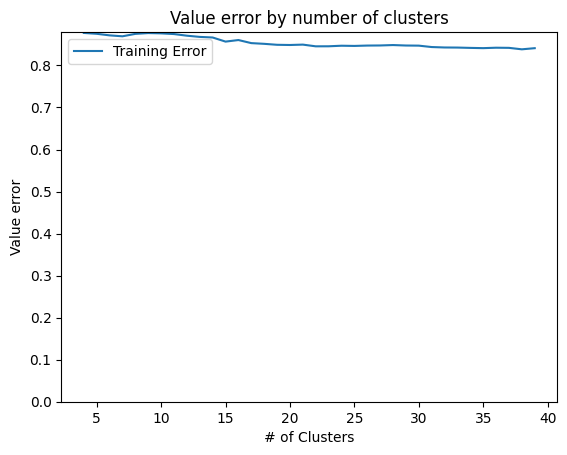

In [ ]:
# Setting parameters for model fitting
max_k = 200
pfeatures = 7
classification = 'DecisionTreeClassifier'
split_classifier_params = {'random_state':0, 'max_depth':2}
clustering = 'Agglomerative'
n_clusters = None
distance_threshold = 0.5 #for Agglomerative clustering
random_state = 0
h = 5
gamma = 1
cv = 5
th = 0.05
eta=25
precision_thresh = 1e-14
eval_samples = None

#Data size
# Ns = [100]
Ns = [100, 200, 500, 1000]
# Ns = [100, 300, 500, 1000, 1500, 2000, 2500, 3000]
df_full = df.copy()

models=[]

# Training models using different Data size
for n in Ns:
    df_small = df_full.loc[df_full['ID']<n]
    print("Trajectories:", df_small["ID"].nunique())
    print("Transitions:", len(df_small))

    print("Mean trajectory length:",
      len(df_small) / df_small["ID"].nunique())

    print("Action counts:")
    print(df_small["ACTION"].value_counts())

    print("Reward counts:")
    print(df_small["RISK"].value_counts())

    m = MDP_model()
    print('Training for N=', n, ' .....')
    m.fit(df_small, # df: dataframe in the format ['ID', 'TIME', ...features..., 'RISK', 'ACTION']
        pfeatures, # int: number of features
        h, # int: time horizon (# of actions we want to optimize)
        gamma, # discount factor
        max_k, # int: number of iterations
        distance_threshold, # clustering diameter for Agglomerative clustering
        cv, # number for cross validation
        th, # splitting threshold
        eta, # incoherence threshold, calculated by eta*sqrt(datapoints)/clusters
        precision_thresh, # precision threshold
        classification, # classification method
        split_classifier_params, # classifier params
        clustering,# clustering method from Agglomerative, KMeans, and Birch
        n_clusters, # number of clusters for KMeans
        random_state,
        eval_samples = eval_samples,
        verbose=True,
        stochastic=True,
        plot=True)
    models.append(m)

In [ ]:
for i, m in enumerate(models):

  print(f"Model {i}")
  print(m.max_std_history)

Model 0
[[3, 39.38908478246227, 1.0], [4, 45.11866499575197, 1.0], [5, 26.502477577342553, 0.5873949856414817], [6, 23.162036935939234, 0.5133582063680296], [7, 17.755599166249034, 0.39353112881156316], [8, 13.98811761044291, 0.31002951022065756], [9, 12.120739308614901, 0.2686413551854005], [10, 11.113055385446437, 0.24630727408474423], [11, 9.056602693414323, 0.20072851655223006], [12, 11.239884739017329, 0.24911829151140866], [13, 8.762190544132705, 0.19420323152198068], [14, 8.496460742764071, 0.1883136556359554], [15, 6.672836116440948, 0.147895247278908], [16, 6.487379188378702, 0.1437848214035035], [17, 6.225934882663805, 0.13799022828467977], [18, 5.894137368631569, 0.13063634239148067], [19, 5.735627585786563, 0.1271231670158367], [20, 5.354025687114415, 0.11866542788042397], [21, 5.228319231843455, 0.11587929812053865], [22, 4.92638116707486, 0.10918721038263633], [23, 4.898979485566357, 0.10857988564217508], [24, 4.614160399826566, 0.10226721912674056], [25, 4.59947928742864

In [ ]:

q = 0.95

for idx, m in enumerate(models):

    errors = np.array(m.training_error)

    clusters = np.arange(3, 3 + len(errors))

    start_error = errors[0]
    best_error = errors.min()

    threshold = best_error + (1-q)*(start_error-best_error)

    opt_idx = np.where(errors <= threshold)[0][0]
    opt_k = clusters[opt_idx]

    print(f"Model {idx}")
    print(f"  best error = {best_error:.4f}")
    print(f"  opt_k      = {opt_k}")

Model 0
  best error = 0.6046
  opt_k      = 100
Model 1
  best error = 0.6611
  opt_k      = 153
Model 2
  best error = 0.7543
  opt_k      = 173
Model 3
  best error = 0.7853
  opt_k      = 118


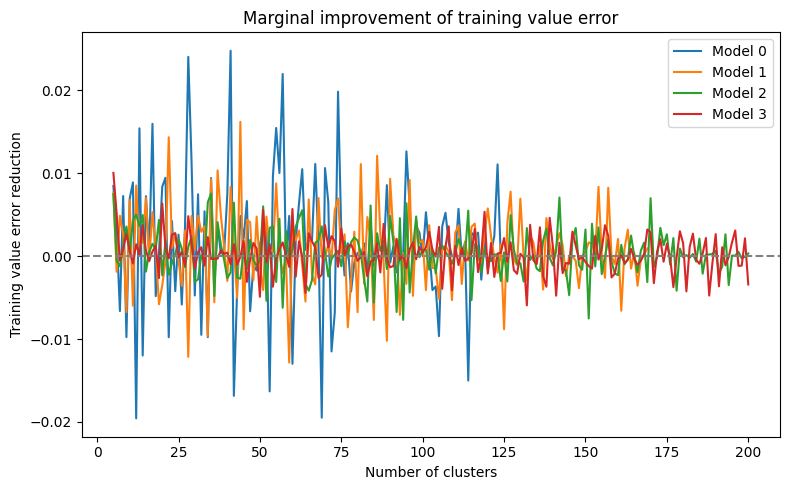

In [ ]:
plt.figure(figsize=(8,5))

for i, m in enumerate(models):

    history = np.asarray(m.training_error)

    # 两列分别取出
    clusters = history[:, 0]
    errors = history[:, 1]

    # 一阶差分（正数表示误差下降）
    improvement = errors[:-1] - errors[1:]

    plt.plot(
        clusters[1:],
        improvement,
        label=f"Model {i}"
    )

plt.axhline(0, color='gray', linestyle='--')

plt.xlabel("Number of clusters")
plt.ylabel("Training value error reduction")
plt.title("Marginal improvement of training value error")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

for i, m in enumerate(models):

    errors = np.array(m.training_error)
    print(errors)

[[  4.           0.80062476]
 [  5.           0.79214898]
 [  6.           0.78930349]
 [  7.           0.79592713]
 [  8.           0.78866977]
 [  9.           0.79843597]
 [ 10.           0.79151753]
 [ 11.           0.78262379]
 [ 12.           0.80218452]
 [ 13.           0.78676553]
 [ 14.           0.79874902]
 [ 15.           0.79151753]
 [ 16.           0.79120162]
 [ 17.           0.7752419 ]
 [ 18.           0.7800641 ]
 [ 19.           0.77974355]
 [ 20.           0.77136243]
 [ 21.           0.76190551]
 [ 22.           0.77168646]
 [ 23.           0.76746335]
 [ 24.           0.77168646]
 [ 25.           0.76909037]
 [ 26.           0.77491935]
 [ 27.           0.77136243]
 [ 28.           0.74732858]
 [ 29.           0.73586684]
 [ 30.           0.74060786]
 [ 31.           0.73314391]
 [ 32.           0.74263046]
 [ 33.           0.73722452]
 [ 34.           0.74699398]
 [ 35.           0.73756356]
 [ 36.           0.74060786]
 [ 37.           0.73688534]
 [ 38.        

<Figure size 800x500 with 0 Axes>

baseline policy:   0%|          | 0/5000 [00:00<?, ?it/s]

MRL model 0:   0%|          | 0/5000 [00:00<?, ?it/s]

MRL model 1:   0%|          | 0/5000 [00:00<?, ?it/s]

MRL model 2:   0%|          | 0/5000 [00:00<?, ?it/s]

MRL model 3:   0%|          | 0/5000 [00:00<?, ?it/s]

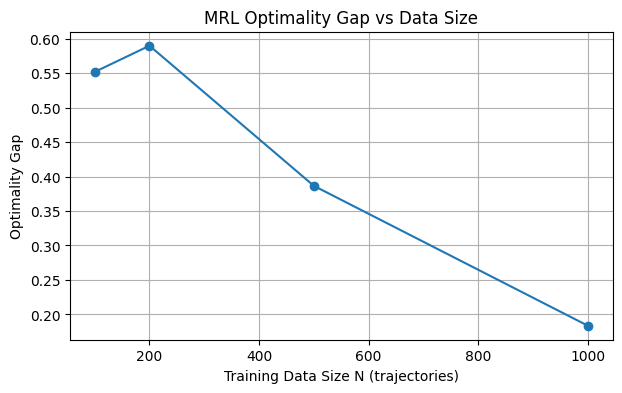

In [ ]:
true_pi_dg = true_pi[:720]   # 去掉 sink node

gaps = value_diff(
    models=models,
    baseline_pi=true_pi_dg,
    num_states=720,
    num_iters=5000,          # 每个 policy rollout 评估1000条轨迹
    max_num_steps=20,
    idx_type="obs",
    diabetic_idx=0,
    gamma=0.99,
    min_action_obs=1,
    epsilon=1e-4,
    p_diabetes=0.2,
    use_median=False,
    use_tqdm=True,
)

plt.figure(figsize=(7, 4))
plt.plot(Ns, gaps, marker="o")
plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Optimality Gap")
plt.title("MRL Optimality Gap vs Data Size")
plt.grid(True)
plt.show()

In [ ]:
rows = []

for n, m in zip(Ns, models):
    cluster_sizes = m.df_trained.groupby("CLUSTER").size()
    rows.append({
        "N": n,
        "clusters": m.df_trained["CLUSTER"].nunique(),
        "len_pi": len(m.pi),
        "min_cluster_size": cluster_sizes.min(),
        "median_cluster_size": cluster_sizes.median(),
        "num_tiny_clusters_<=5": int((cluster_sizes <= 5).sum()),
        "num_tiny_clusters_<=10": int((cluster_sizes <= 10).sum()),
        "pi_unique": np.unique(m.pi, return_counts=True),
    })

pd.DataFrame(rows)

,N,clusters,len_pi,min_cluster_size,median_cluster_size,num_tiny_clusters_<=5,num_tiny_clusters_<=10,pi_unique
0,100,46,48,1,18.0,3,11,"([0, 1, 2, 3, 4, 5, 6, 7], [10, 2, 4, 2, 8, 4,..."
1,200,51,53,4,31.0,1,1,"([0, 1, 2, 3, 4, 5, 6, 7], [10, 5, 4, 3, 14, 3..."
2,500,34,36,28,125.5,0,0,"([0, 1, 2, 3, 4, 5, 6, 7], [6, 3, 3, 3, 3, 1, ..."
3,1000,38,40,11,212.0,0,0,"([0, 2, 3, 4, 5, 6, 7], [8, 3, 5, 3, 1, 14, 6])"


In [ ]:
for i, model in enumerate(models):
    punishment_idx = model.P.shape[1] - 1
    to_punish = model.P[:, :-1, punishment_idx] == 1

    print("model", i)
    print("to punishment count:", to_punish.sum())
    print("total state-action pairs:", to_punish.size)

model 0
to punishment count: 160
total state-action pairs: 224
model 1
to punishment count: 8
total state-action pairs: 40
model 2
to punishment count: 141
total state-action pairs: 208
model 3
to punishment count: 346
total state-action pairs: 376


In [ ]:
m = models[0]   # 或报错对应的那个model

print("len(pi):", len(m.pi))
print("state_map:", m.state_map)
print("inverse_state_map:", m.inverse_state_map)

print("unique labels in classifier:")
print(np.unique(m.m.predict(m.df_trained[[f"FEATURE_{i}" for i in range(7)]])))

len(pi): 48
state_map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 13: 10, 14: 11, 15: 12, 16: 13, 17: 14, 18: 15, 19: 16, 20: 17, 21: 18, 22: 19, 23: 20, 24: 21, 25: 22, 26: 23, 27: 24, 28: 25, 29: 26, 30: 27, 31: 28, 32: 29, 33: 30, 34: 31, 35: 32, 36: 33, 37: 34, 38: 35, 39: 36, 40: 37, 41: 38, 42: 39, 43: 40, 44: 41, 45: 42, 46: 43, 47: 44, 48: 45, 49: 46}
inverse_state_map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 13, 11: 14, 12: 15, 13: 16, 14: 17, 15: 18, 16: 19, 17: 20, 18: 21, 19: 22, 20: 23, 21: 24, 22: 25, 23: 26, 24: 27, 25: 28, 26: 29, 27: 30, 28: 31, 29: 32, 30: 33, 31: 34, 32: 35, 33: 36, 34: 37, 35: 38, 36: 39, 37: 40, 38: 41, 39: 42, 40: 43, 41: 44, 42: 45, 43: 46, 44: 47, 45: 48, 46: 49}
unique labels in classifier:
[ 0  1  2  3  4  5  6  7  8  9 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]


In [ ]:
print(sorted(m.state_map.keys()))
print(sorted(m.state_map.values()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92]


In [ ]:
baseline_policy_array = deterministic_pi_to_prob_array(true_pi[:720], num_actions=8)

mrl_policy_array = mrl_model_to_prob_array(
    model=m,
    num_states=720,
    idx_type="obs",
    diabetic_idx=0,
    num_actions=8,
)

baseline_actions = baseline_policy_array.argmax(axis=1)
mrl_actions = mrl_policy_array.argmax(axis=1)

print("same actions:", np.sum(baseline_actions == mrl_actions), "/ 720")
print("agreement:", np.mean(baseline_actions == mrl_actions))

diff_states = np.where(baseline_actions != mrl_actions)[0]
print("different states:", len(diff_states))
print(diff_states[:20])

In [ ]:
baseline_value, baseline_returns = estimate_policy_value(
    policy_array=baseline_policy_array,
    num_iters=1000,
    max_num_steps=20,
    gamma=0.99,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=0.2,
    use_tqdm=True,
    tqdm_desc="baseline debug",
)

mrl_value, mrl_returns = estimate_policy_value(
    policy_array=mrl_policy_array,
    num_iters=1000,
    max_num_steps=20,
    gamma=0.99,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=0.2,
    use_tqdm=True,
    tqdm_desc="mrl debug",
)

print("baseline_value:", baseline_value)
print("mrl_value:", mrl_value)
print("gap:", abs(mrl_value - baseline_value))

print("baseline return counts:", np.unique(baseline_returns, return_counts=True))
print("mrl return counts:", np.unique(mrl_returns, return_counts=True))

print(np.unique(baseline_returns, return_counts=True))

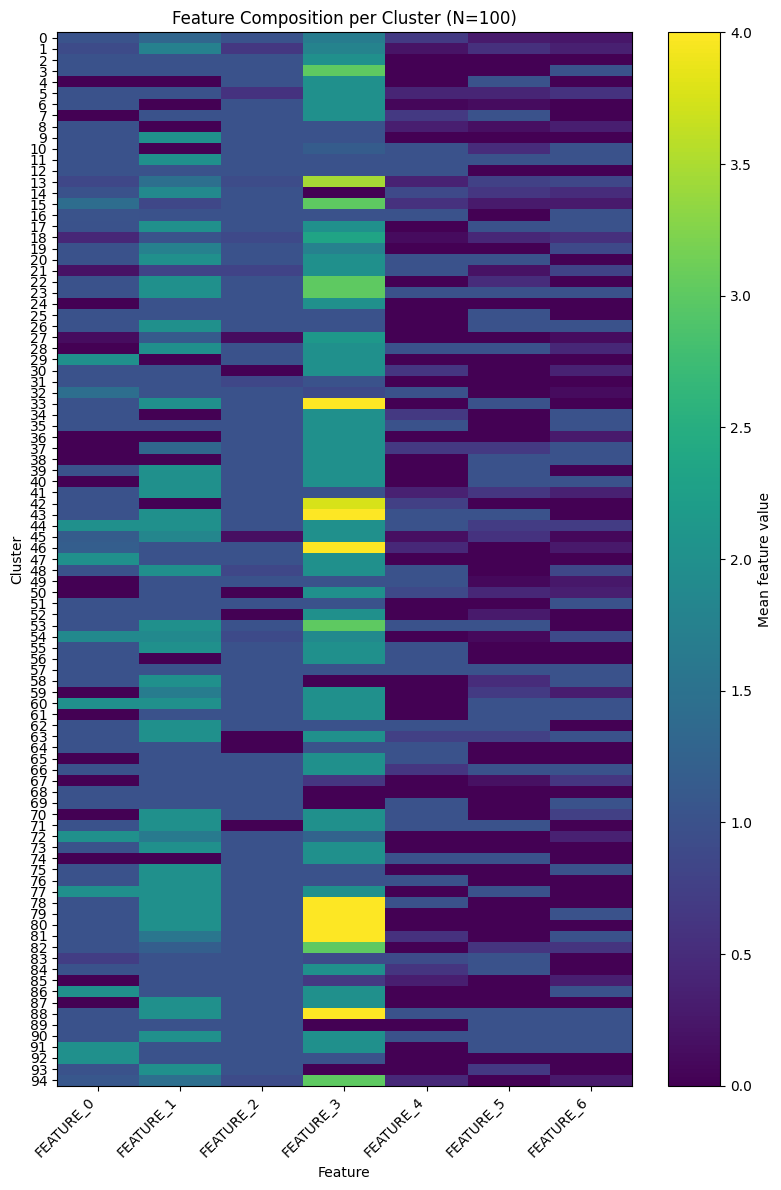

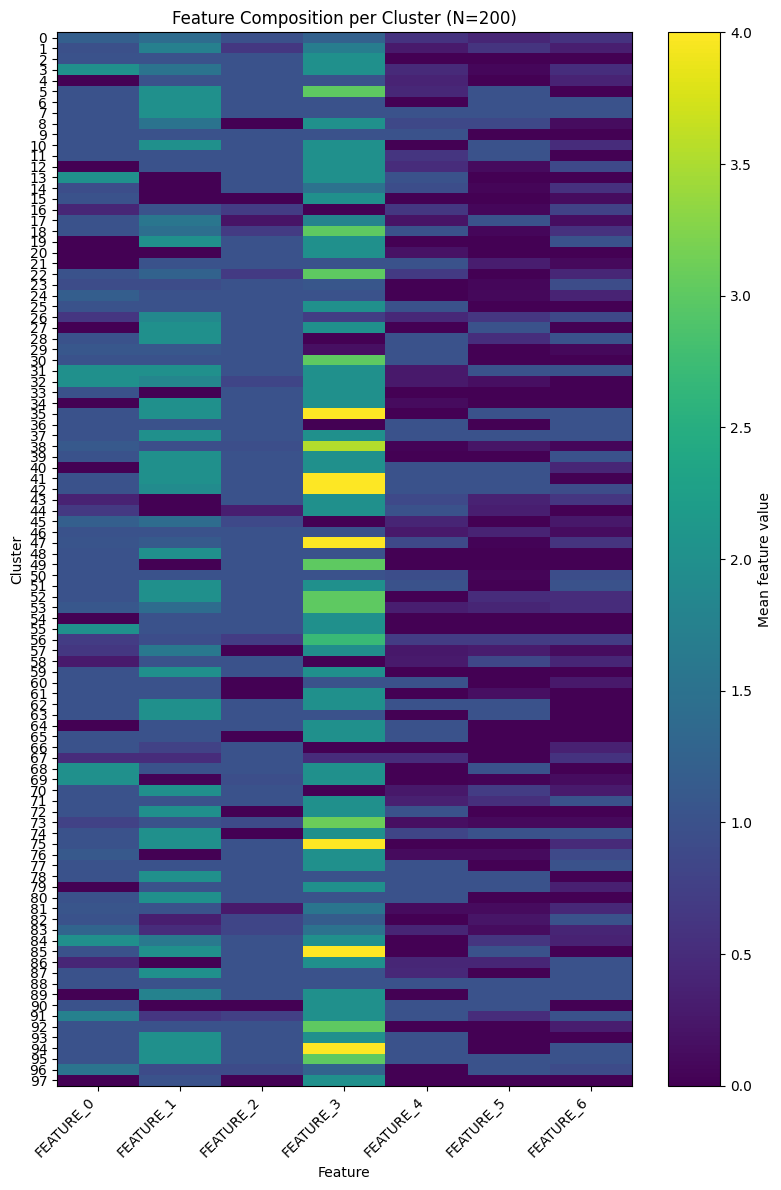

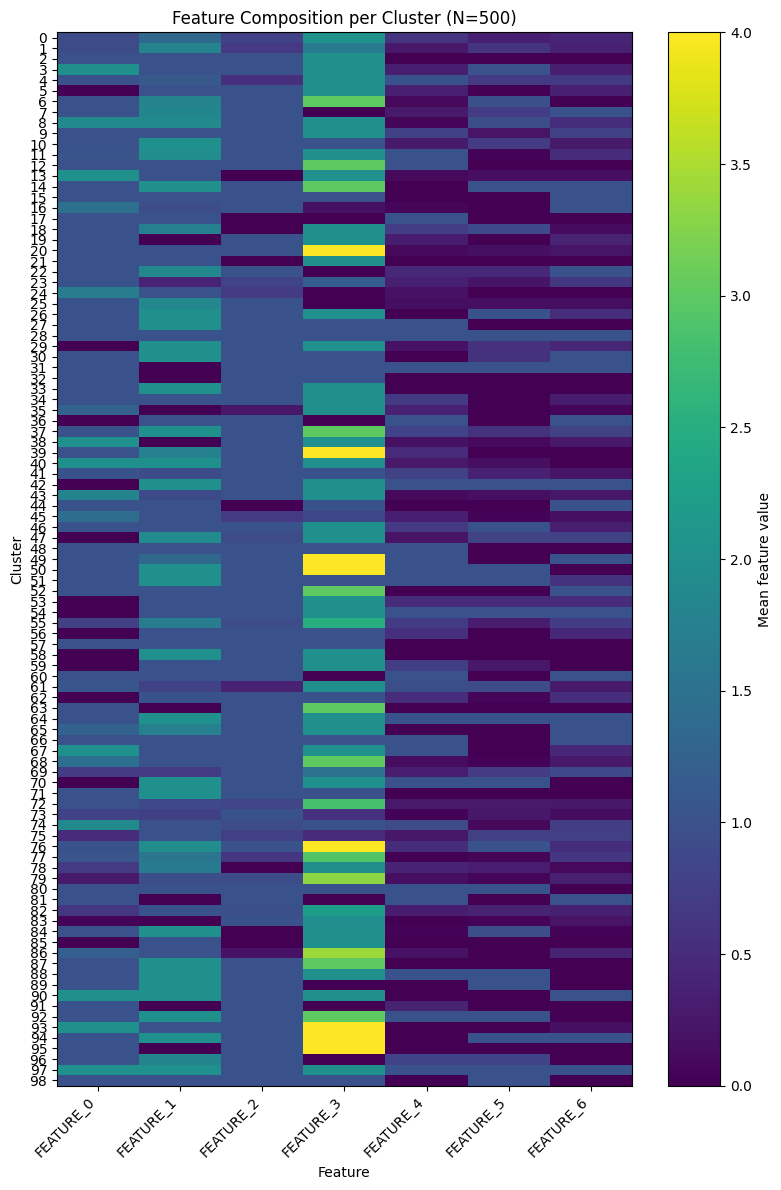

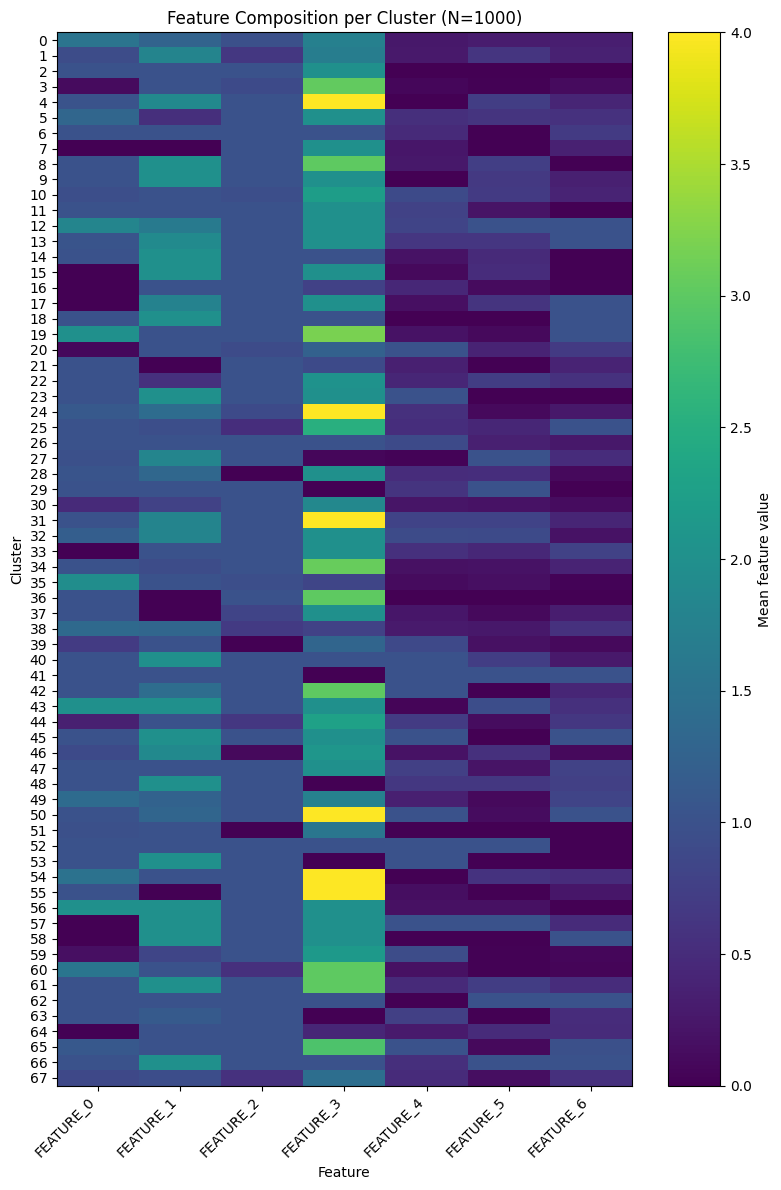

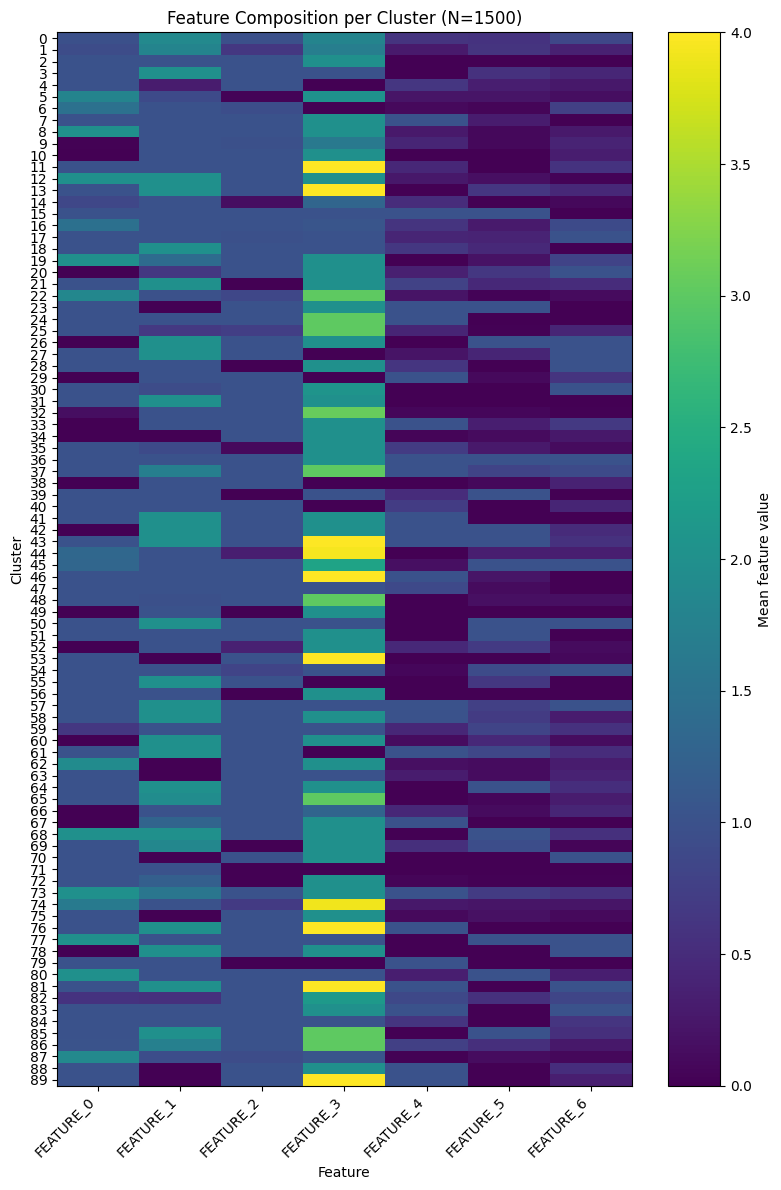

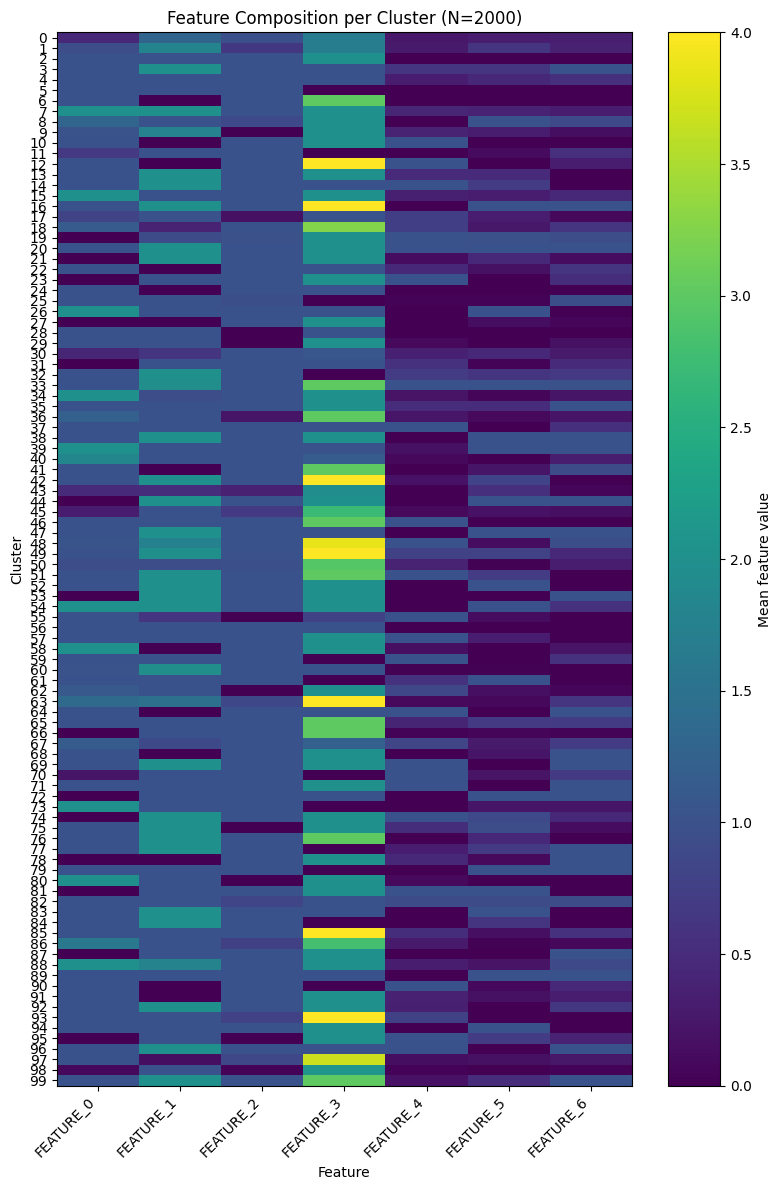

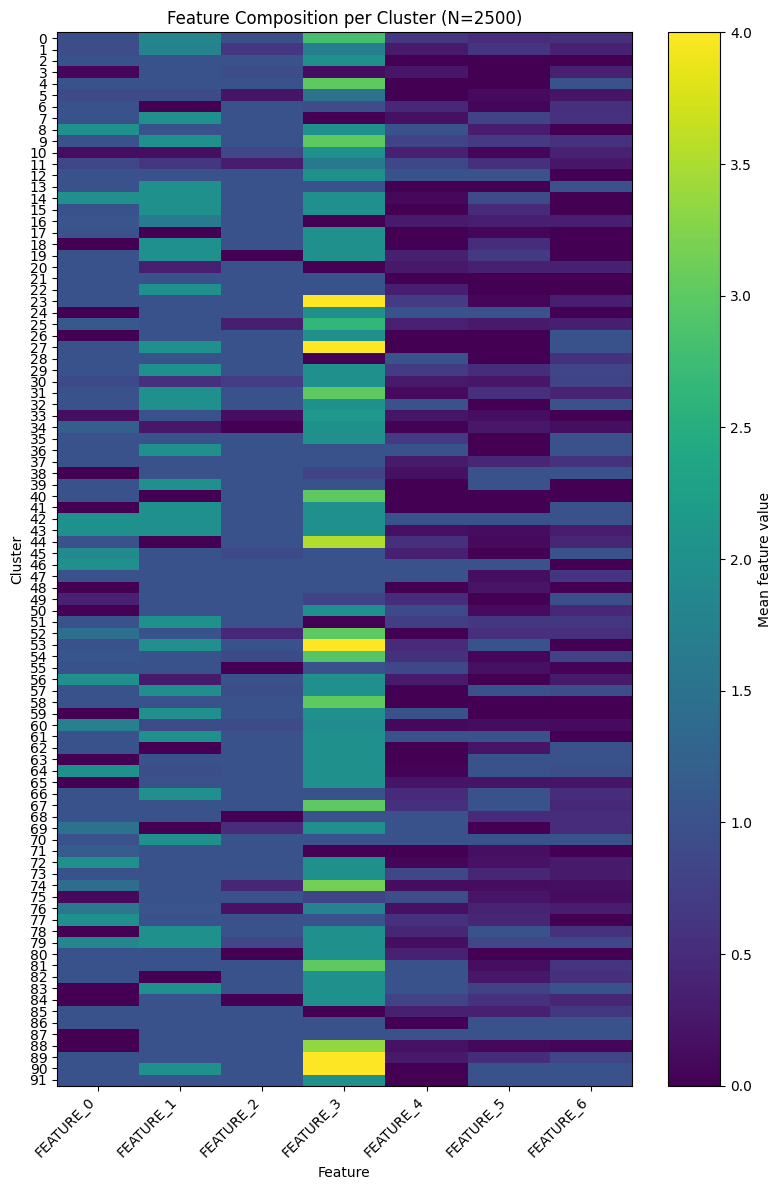

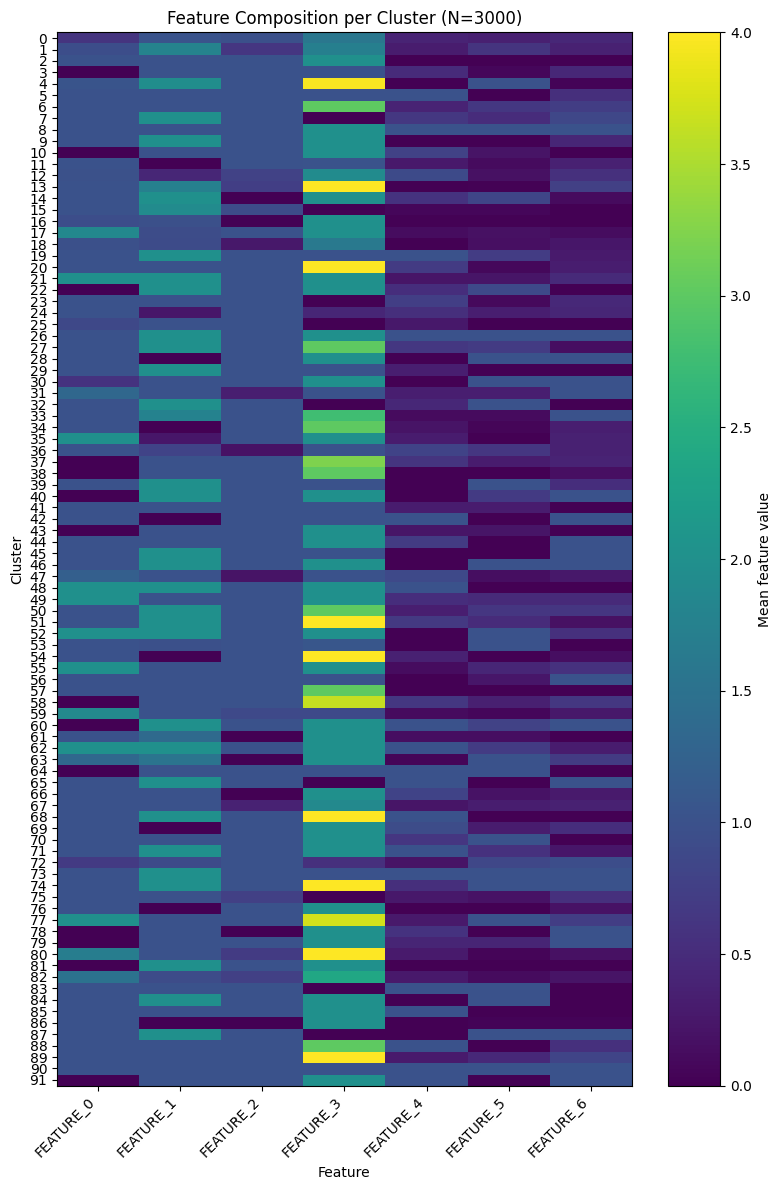

In [ ]:
Ns = [100, 200, 500, 1000, 1500, 2000, 2500, 3000]

for n, m in zip(Ns, models):

    cluster_feature_means = (
        m.df_trained
        .groupby("CLUSTER")[[f"FEATURE_{i}" for i in range(7)]]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(8, 12))

    plt.imshow(cluster_feature_means, aspect="auto")
    plt.colorbar(label="Mean feature value")

    plt.xticks(
        range(7),
        [f"FEATURE_{i}" for i in range(7)],
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(cluster_feature_means)),
        cluster_feature_means.index
    )

    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.title(f"Feature Composition per Cluster (N={n})")

    plt.tight_layout()
    plt.show()

N = 100


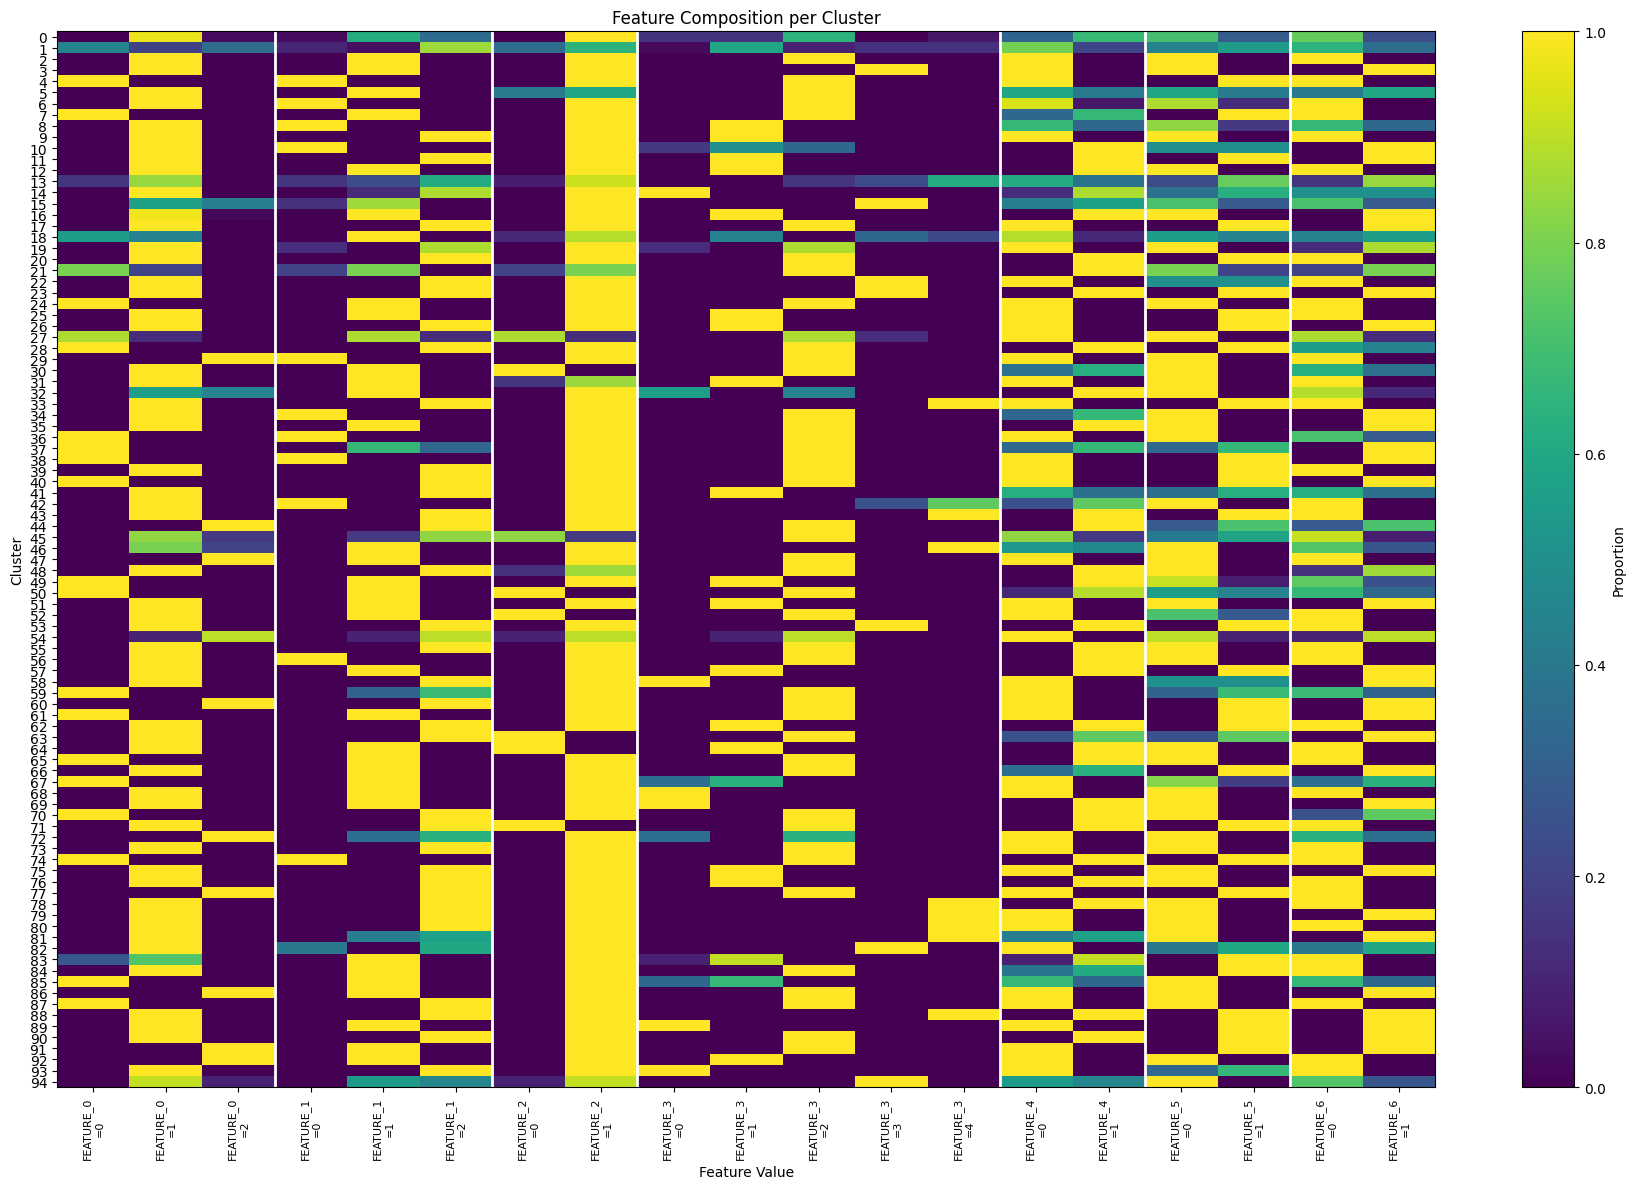

N = 200


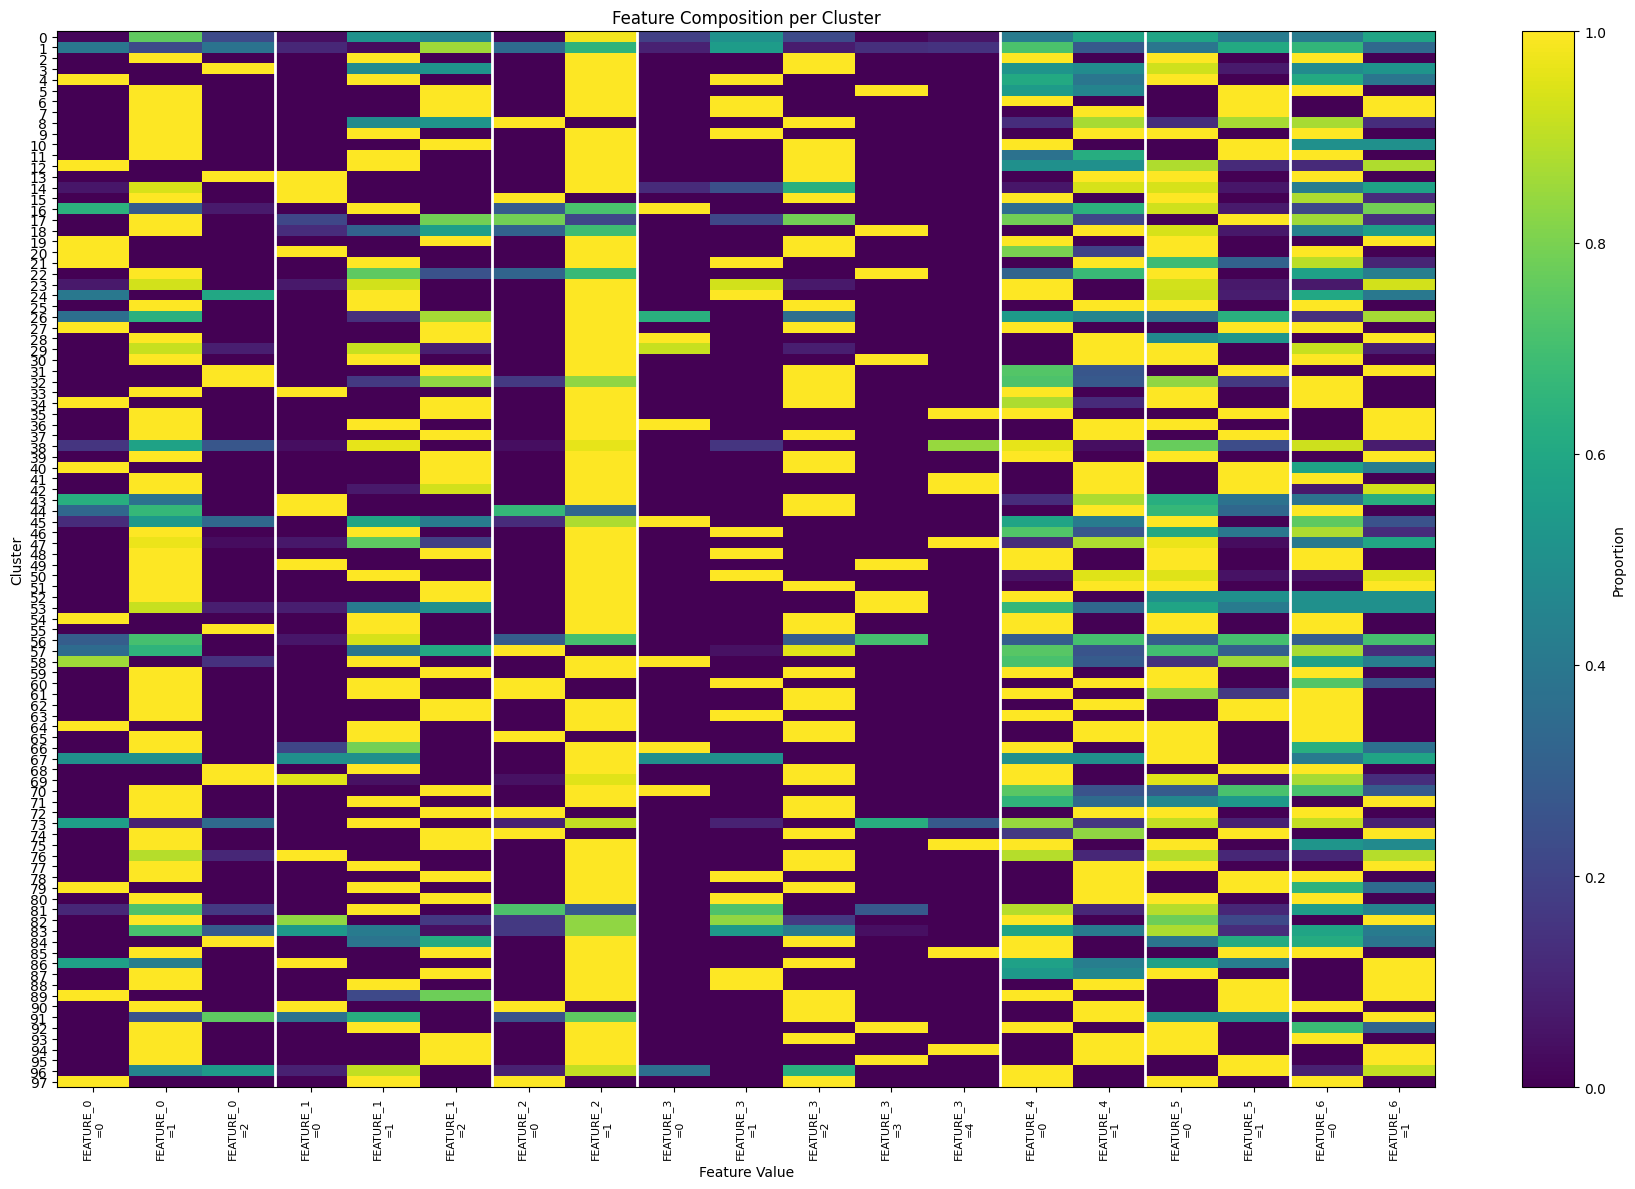

N = 500


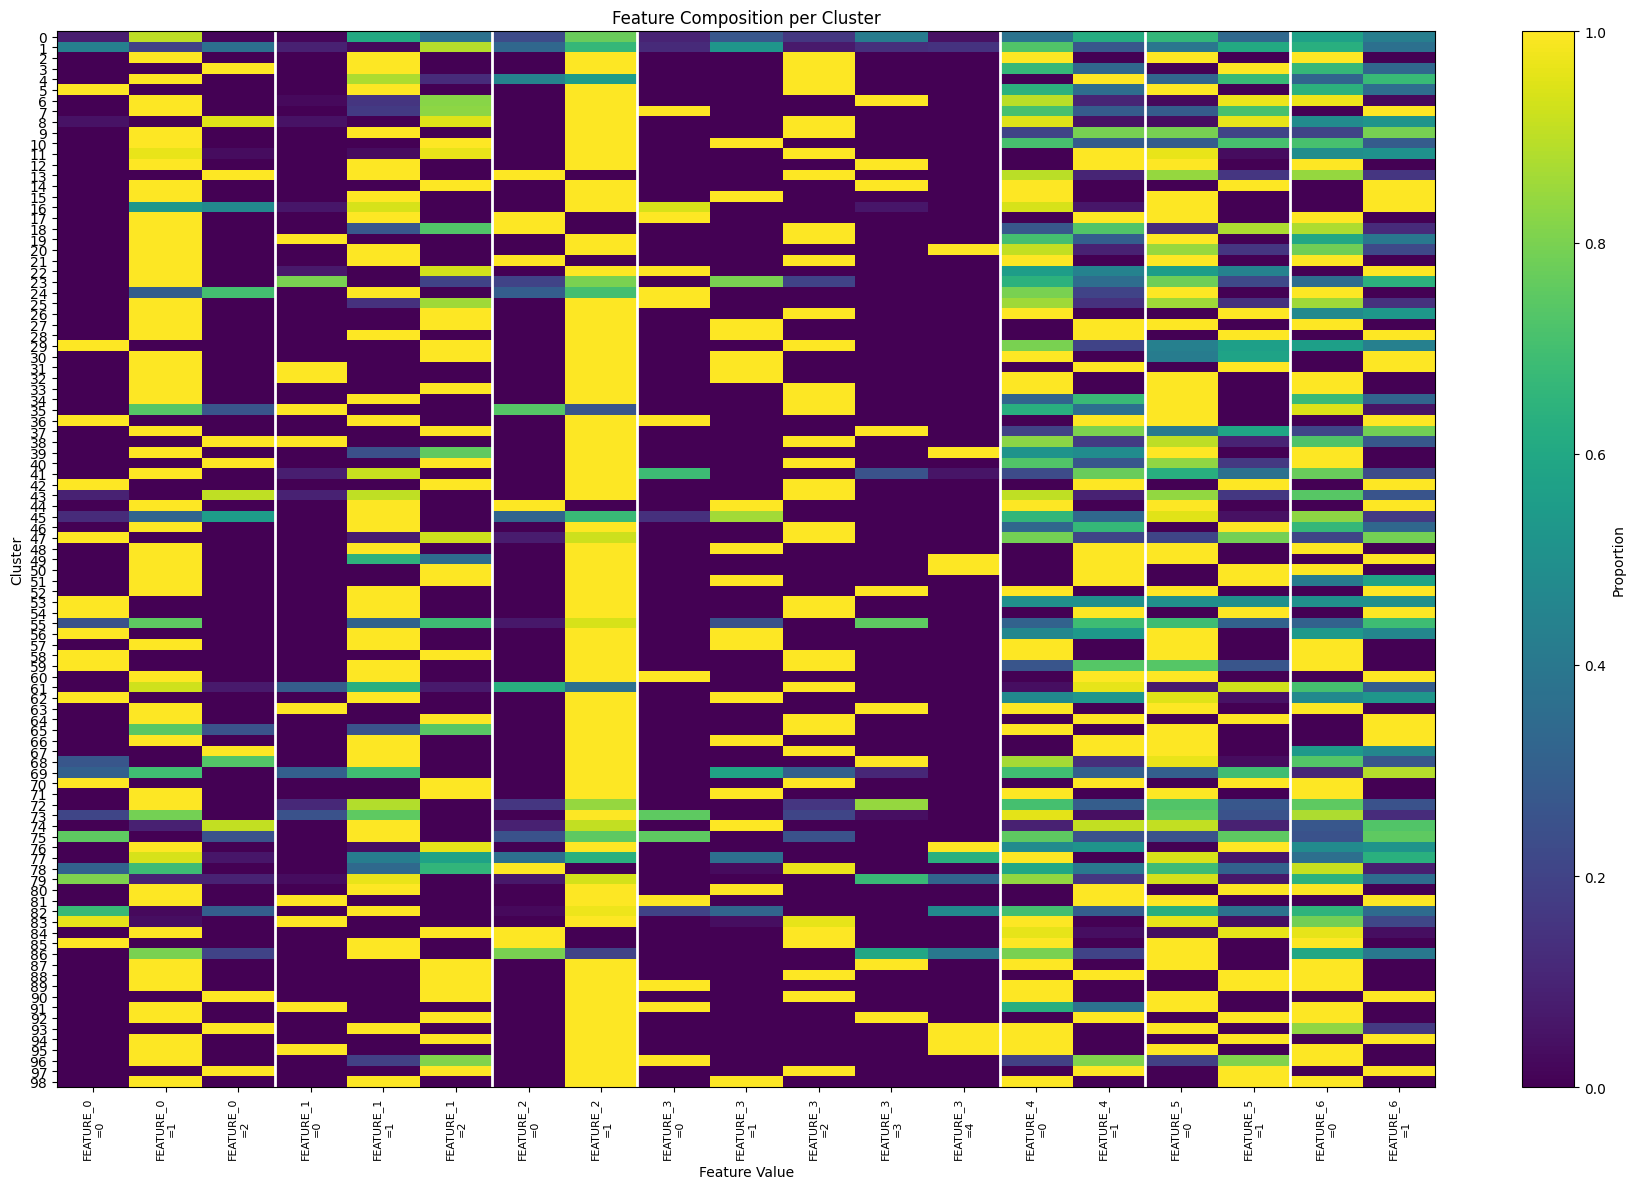

N = 1000


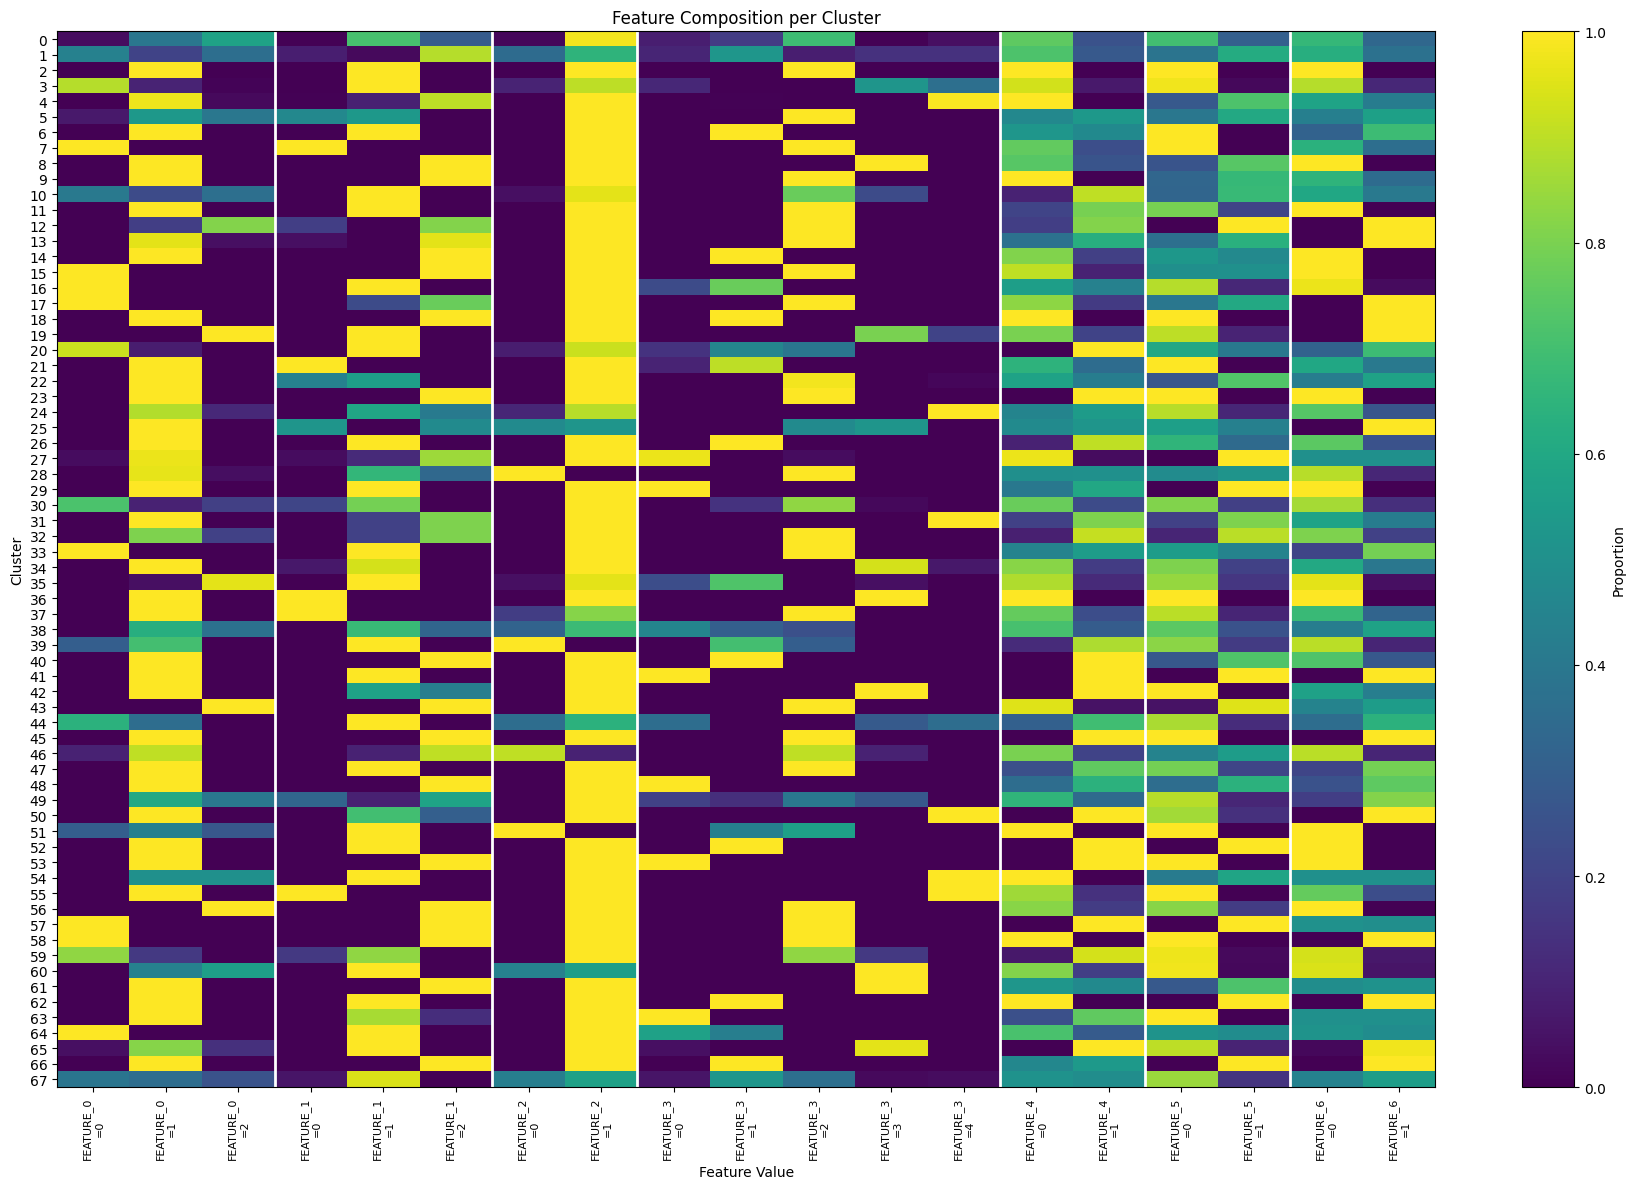

N = 1500


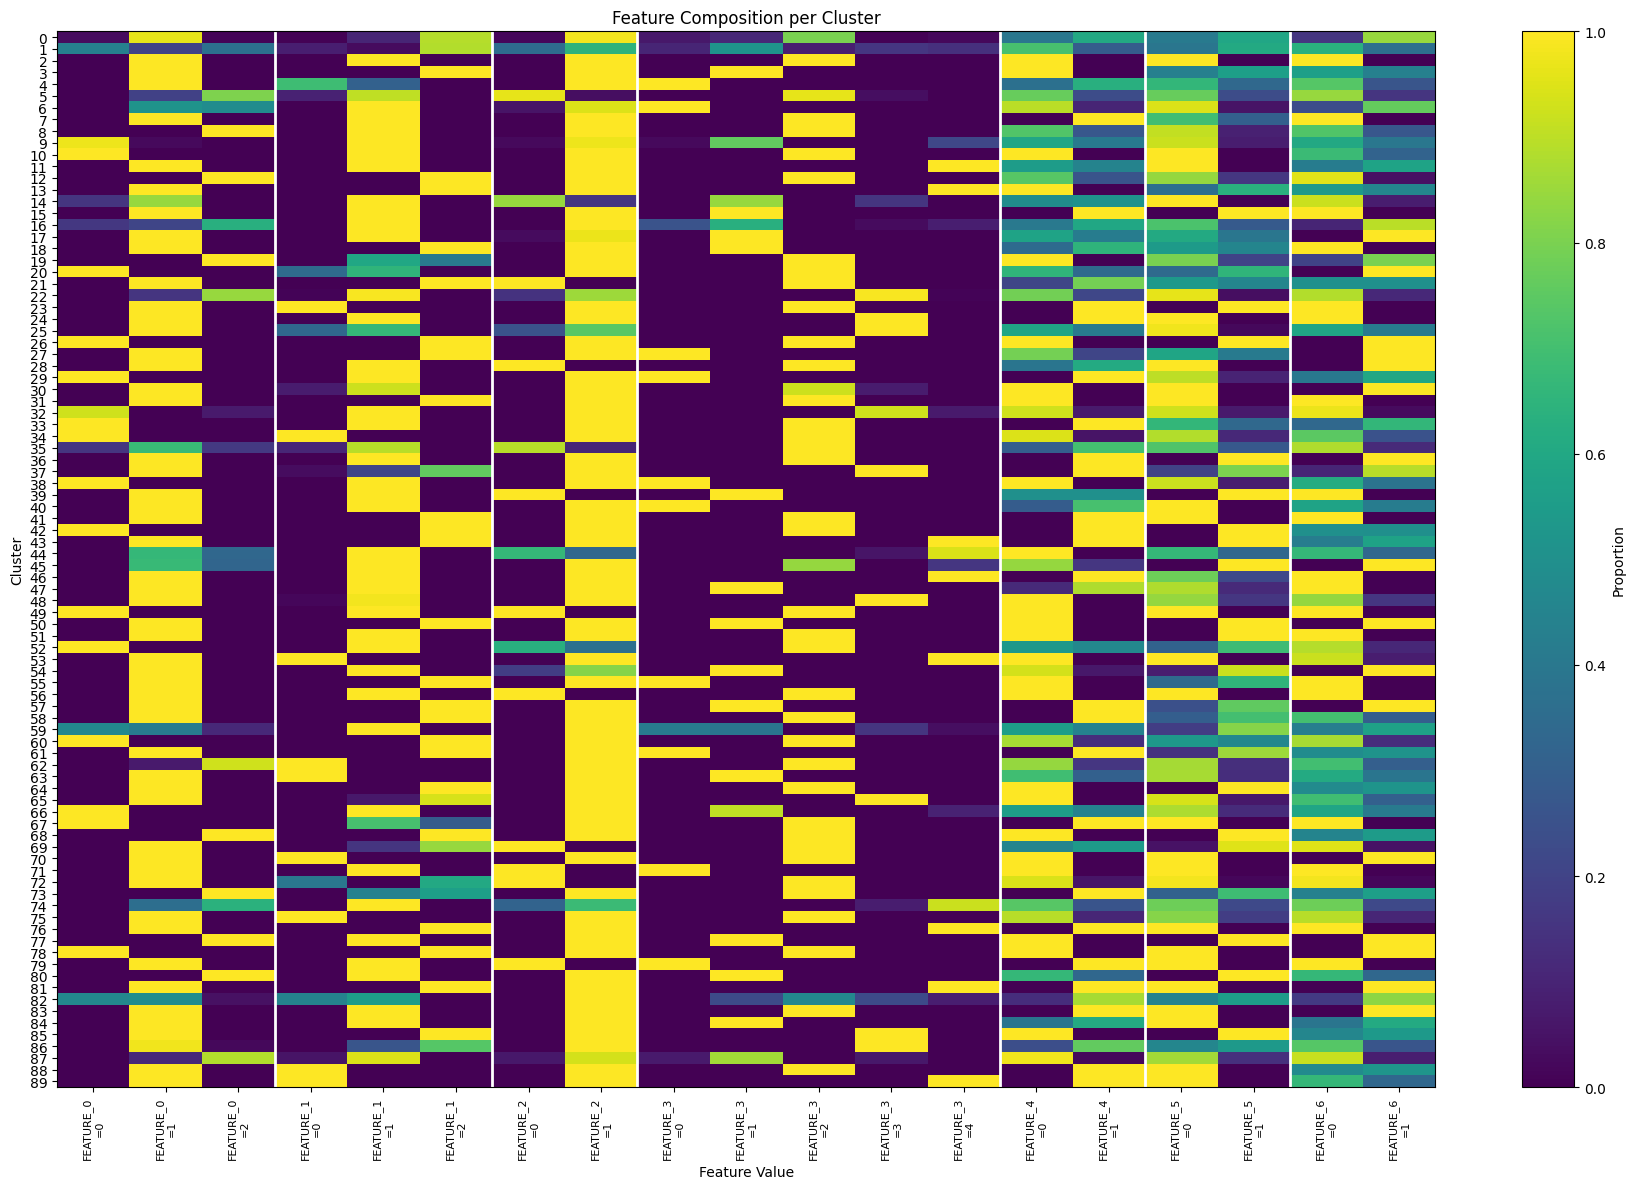

N = 2000


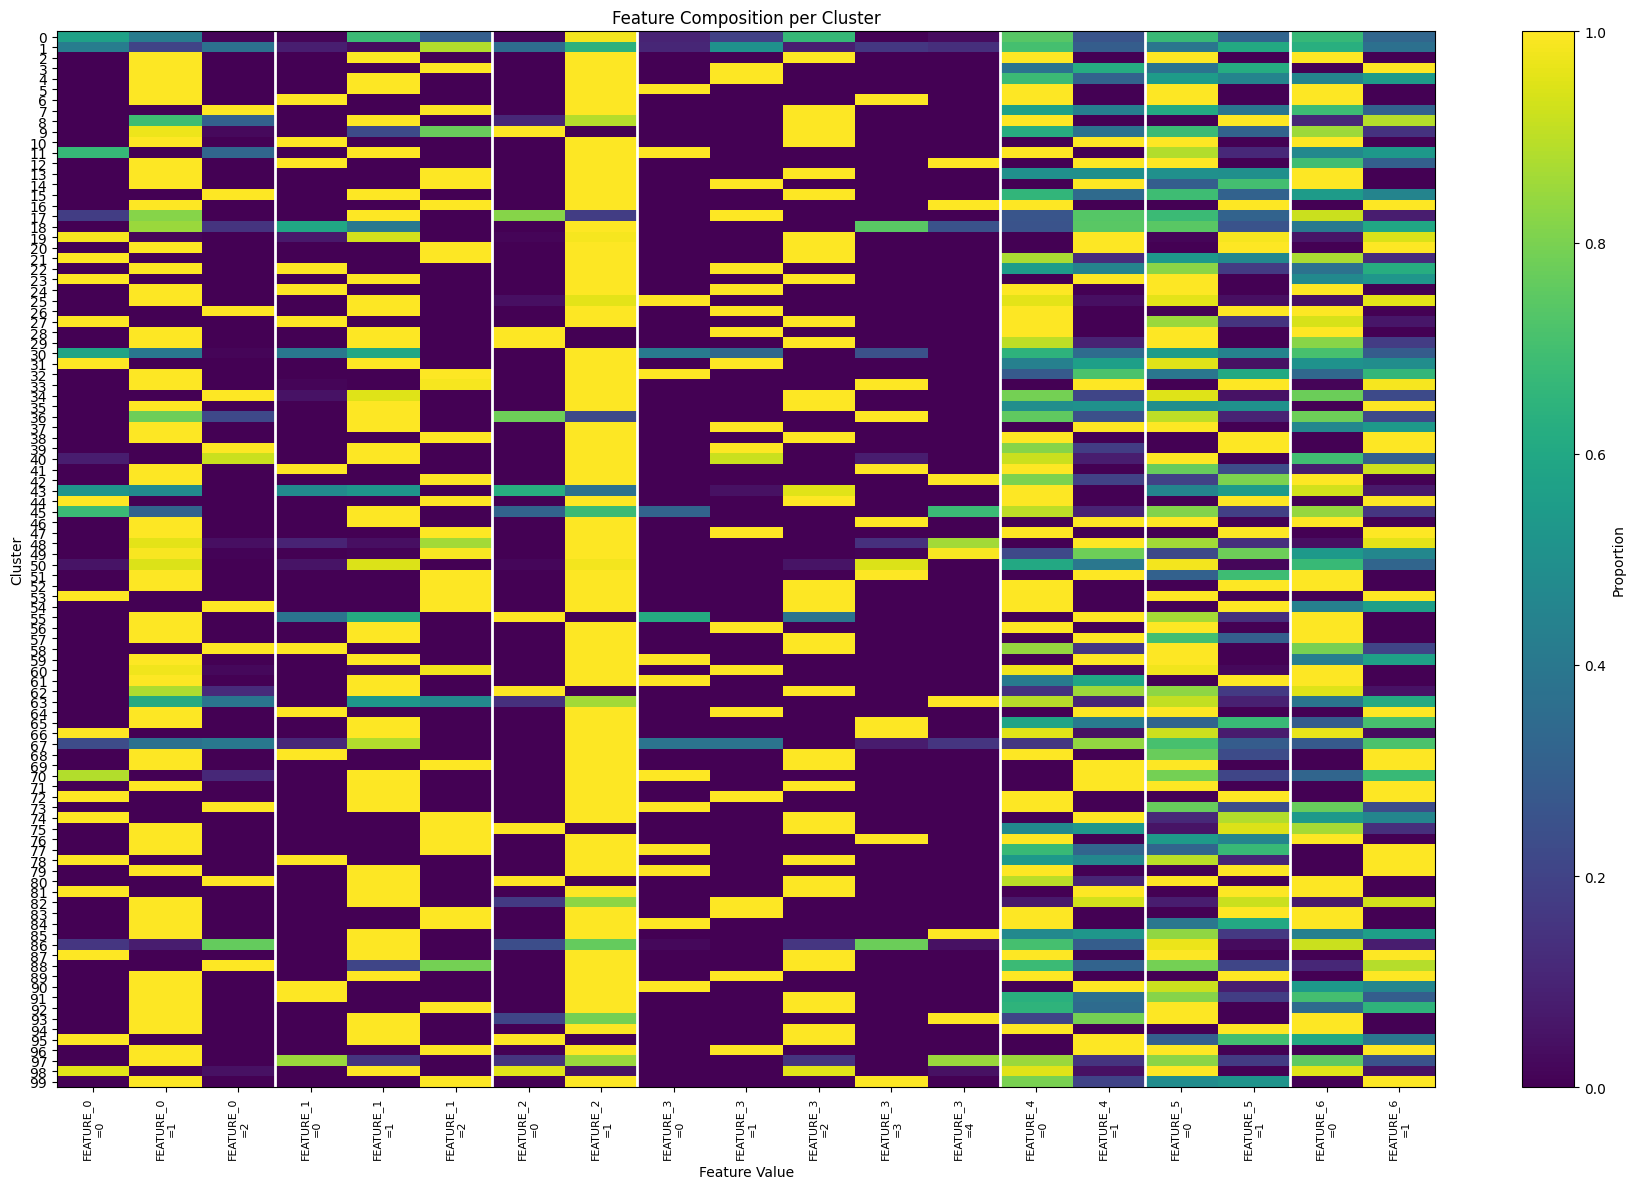

N = 2500


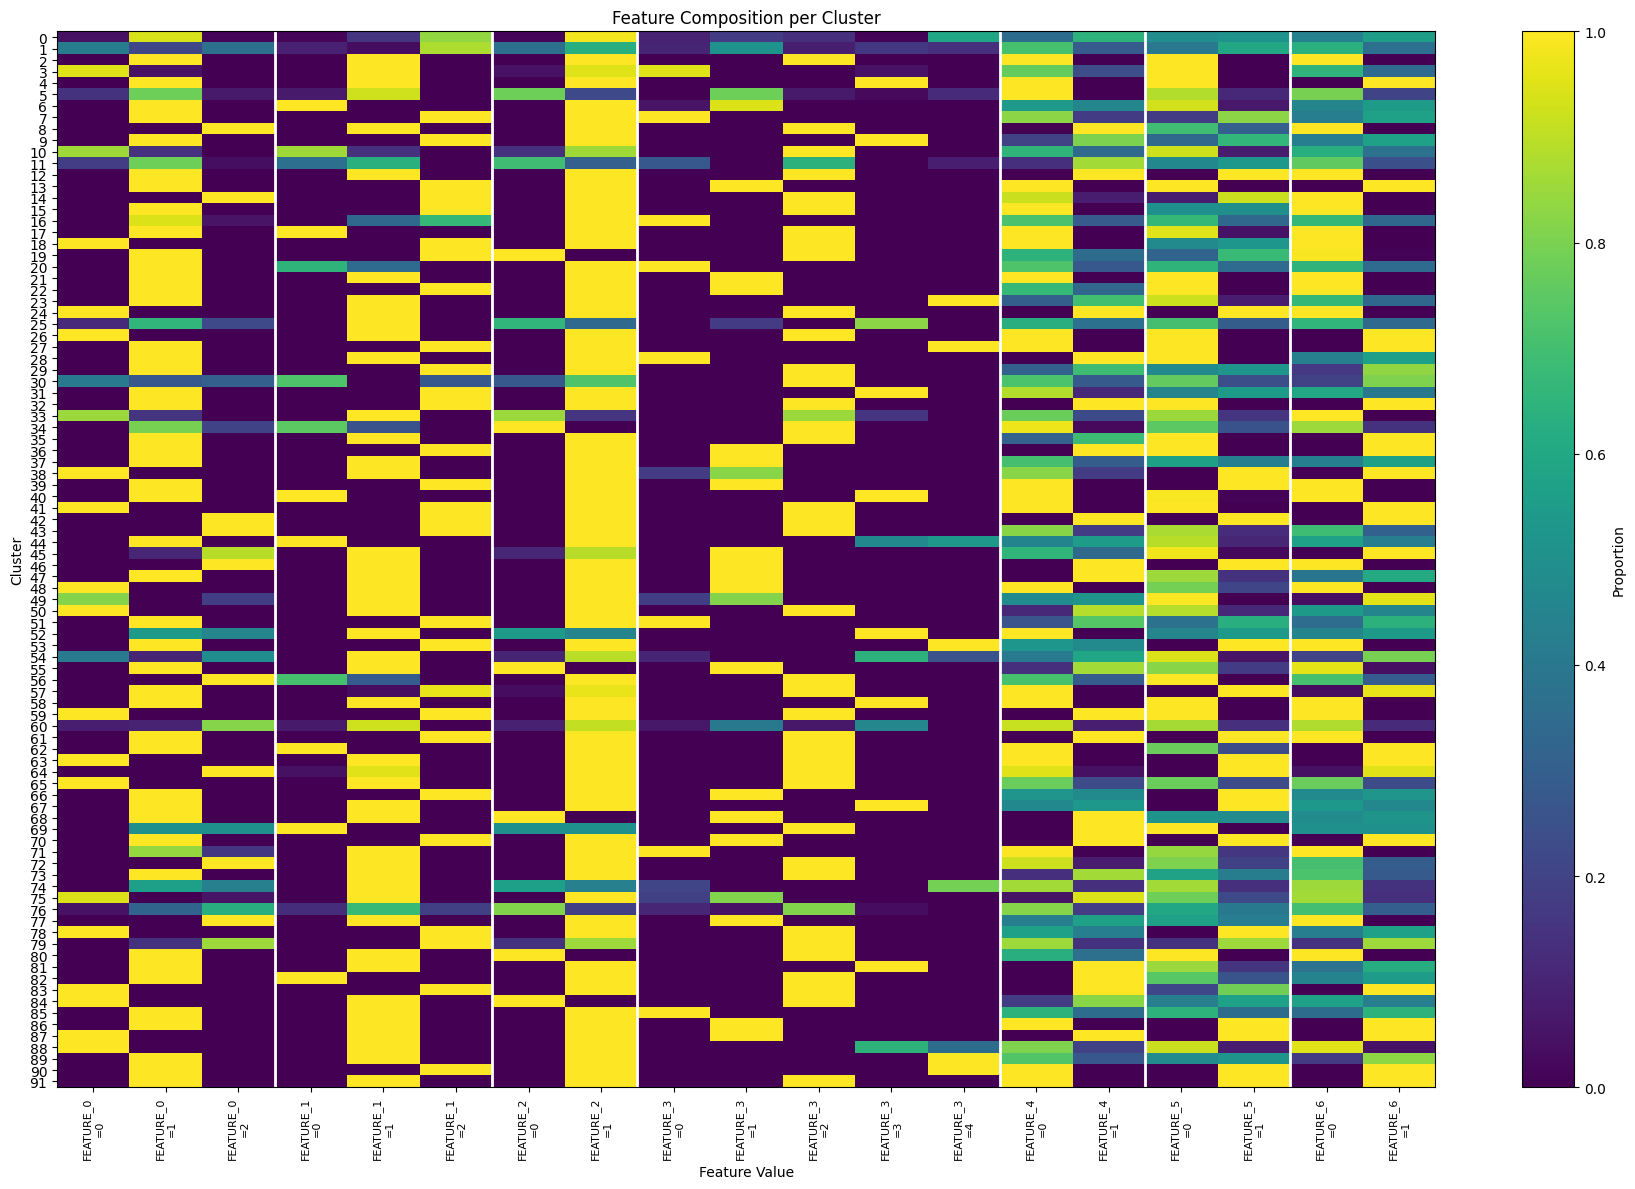

N = 3000


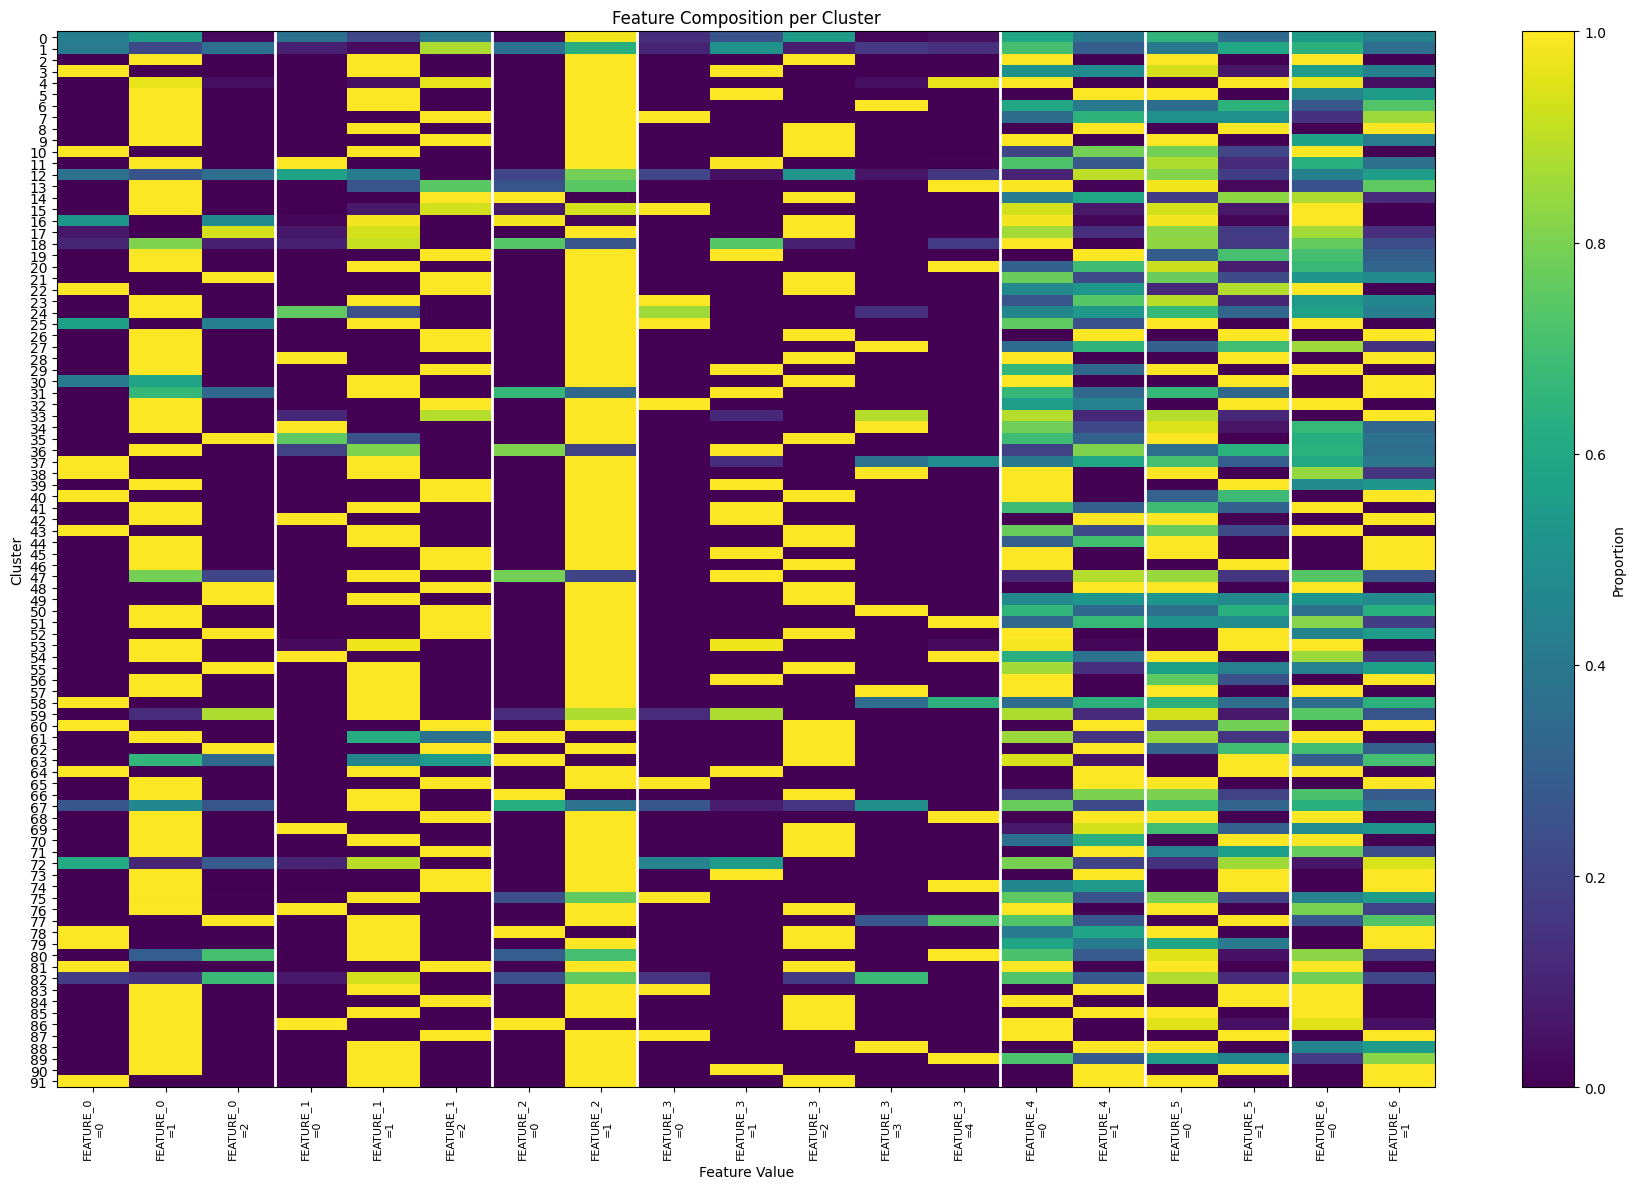

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_cluster_feature_proportion_heatmap(
    df_trained,
    pfeatures=7,
    cluster_col="CLUSTER",
    figsize=(18, 12),
):
    """
    Rows: clusters
    Columns: (feature, value)
    Color: proportion of samples in that cluster having that value.
    """

    feature_cols = [f"FEATURE_{i}" for i in range(pfeatures)]

    tables = []
    xtick_labels = []
    separators = []

    for feat in feature_cols:

        # proportion table
        tab = (
            df_trained
            .groupby(cluster_col)[feat]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .sort_index(axis=1)
        )

        # MultiIndex columns
        tab.columns = pd.MultiIndex.from_product([[feat], tab.columns])

        tables.append(tab)

    # concatenate all features
    heatmap = pd.concat(tables, axis=1).fillna(0)
    heatmap = heatmap.sort_index()

    # x tick labels
    for feat, value in heatmap.columns:
        xtick_labels.append(f"{feat}\n={value}")

    # feature boundaries
    start = 0
    for tab in tables[:-1]:
        start += tab.shape[1]
        separators.append(start - 0.5)

    plt.figure(figsize=figsize)

    plt.imshow(
        heatmap.values,
        aspect="auto",
        interpolation="nearest",
        vmin=0,
        vmax=1,
    )

    plt.colorbar(label="Proportion")

    plt.xticks(
        np.arange(len(xtick_labels)),
        xtick_labels,
        rotation=90,
        fontsize=8,
    )

    plt.yticks(
        np.arange(len(heatmap.index)),
        heatmap.index,
    )

    # draw separators between features
    for x in separators:
        plt.axvline(x, color="white", linewidth=2)

    plt.xlabel("Feature Value")
    plt.ylabel("Cluster")
    plt.title("Feature Composition per Cluster")

    plt.tight_layout()
    plt.show()

    return heatmap

Ns = [100, 200, 500, 1000, 1500, 2000, 2500, 3000]

for n, m in zip(Ns, models):

    print(f"N = {n}")

    plot_cluster_feature_proportion_heatmap(
        m.df_trained,
        pfeatures=7,
    )

## Optimality Gap (10 Trials )


In [11]:
# =========================================================
# Repeated experiment settings
# =========================================================
n_repeats = 10
N_full = 3000

Ns = [100]
# Ns = [100, 200, 500, 1000]
# Ns = [100, 200, 500, 1000, 1500, 2000, 2500, 3000]

max_num_steps = 20
p_diabetes = 0.2

nS = State.NUM_OBS_STATES
nA = Action.NUM_ACTIONS_TOTAL

random_policy = np.ones((nS, nA)) / nA

# =========================================================
# Evaluation settings
# =========================================================
gamma_eval = 0.99
num_eval_rollouts = 5000

# Remove sink states from the true policy
true_pi_dg = true_pi[:nS]

true_policy_array = deterministic_pi_to_prob_array(
    true_pi_dg,
    num_actions=nA,
)

# Evaluate true optimal policy once
V_true, true_returns = estimate_policy_value(
    policy_array=true_policy_array,
    num_iters=num_eval_rollouts,
    max_num_steps=max_num_steps,
    gamma=gamma_eval,
    policy_idx_type="obs",
    output_state_idx_type="obs",
    p_diabetes=p_diabetes,
    use_tqdm=True,
    tqdm_desc="True optimal policy",
)

print("Estimated V_true:", V_true)

True optimal policy:   0%|          | 0/5000 [00:00<?, ?it/s]

Estimated V_true: 0.2081669201378858


In [12]:
# =========================================================
# FQI parameters
# =========================================================
fqi_epochs = 100
G_min = -40

# =========================================================
# MRL parameters
# =========================================================
max_k = 200
pfeatures = 7
classification = "DecisionTreeClassifier"
split_classifier_params_base = {"max_depth": 2,}
clustering = "Agglomerative"
n_clusters = None
distance_threshold = 0.5
h = 5
gamma_mrl = 1
cv = 5
th = 0.05
eta = 25
precision_thresh = 1e-14
eval_samples = None

In [13]:
# =========================================================
# Result matrices
# rows: independent repeats
# columns: different N values
# =========================================================
fqi_gap_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

mrl_gap_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

fqi_value_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

mrl_opt_k_matrix = np.full(
    (n_repeats, len(Ns)),
    np.nan,
    dtype=float,
)

# =========================================================
# Save latent-state recovery information
# One entry for each independent repeat
# =========================================================
diabetes_maps = {}
maxN_cluster_maps = {}

N_max = max(Ns)

# Optional: keep fitted models.
# This can consume substantial memory, so it is disabled by default.
# all_mrl_models = []

# =========================================================
# Outer loop: 10 independently generated N=3000 datasets
# =========================================================
for repeat_idx in range(n_repeats):

    data_seed = repeat_idx

    np.random.seed(data_seed)
    random.seed(data_seed)

    print("\n" + "=" * 80)
    print(
        f"Independent experiment "
        f"{repeat_idx + 1}/{n_repeats}, "
        f"data seed={data_seed}"
    )
    print("=" * 80)

    # -----------------------------------------------------
    # 1. Generate one complete N=3000 dataset
    # -----------------------------------------------------
    dg_repeat = DataGenerator()

    (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
    ) = dg_repeat.simulate(
        num_iters=N_full,
        max_num_steps=max_num_steps,
        policy=random_policy,
        policy_idx_type="obs",
        p_diabetes=p_diabetes,
        output_state_idx_type="obs",
        use_tqdm=True,
        tqdm_desc=(
            f"Generating dataset "
            f"{repeat_idx + 1}/{n_repeats}"
        ),
    )

    # diabetes map for MRL diabetic recovery evaluation
    diabetes_map = {}
    for traj in range(iter_component.shape[0]):
      diabetes_map[traj] = int(iter_component[traj, 0, 0])

    diabetes_maps[repeat_idx] = diabetes_map

    # -----------------------------------------------------
    # 2. Convert the same trajectories to both formats
    # -----------------------------------------------------
    df_mrl_full = dg_to_df_mrl(
        iter_states=iter_states,
        iter_actions=iter_actions,
        iter_lengths=iter_lengths,
        iter_rewards=iter_rewards,
        iter_component=iter_component,
    )

    df_fqi_full = dg_to_df_fqi(
        iter_states=iter_states,
        iter_actions=iter_actions,
        iter_lengths=iter_lengths,
        iter_rewards=iter_rewards,
    )

    # Check that both contain the same trajectory IDs
    assert df_mrl_full["ID"].nunique() == N_full
    assert df_fqi_full["ID"].nunique() == N_full

    models = []

    # =====================================================
    # Inner loop: different sample sizes Ns from this dataset
    # =====================================================
    for n_idx, N in enumerate(Ns):

        print("\n" + "-" * 70)
        print(
            f"Repeat={repeat_idx + 1}, "
            f"N={N}"
        )
        print("-" * 70)

        # -------------------------------------------------
        # 3. Use exactly the same trajectory IDs for both
        # -------------------------------------------------
        df_fqi_N = df_fqi_full.loc[
            df_fqi_full["ID"] < N
        ].copy()

        df_mrl_N = df_mrl_full.loc[
            df_mrl_full["ID"] < N
        ].copy()

        assert df_fqi_N["ID"].nunique() == N
        assert df_mrl_N["ID"].nunique() == N

        # =================================================
        # 4. FQI fit and evaluation
        # =================================================
        print(f"\nFQI fitting: repeat={repeat_idx + 1}, N={N}")

        Qs_N = run_tabular_FQI(
            df_data=df_fqi_N,
            gamma=gamma_eval,
            n_epochs=fqi_epochs,
            nS=nS,
            nA=nA,
            G_min=G_min,
            use_tqdm=True,
        )

        Q_N = Qs_N[-1]

        pi_fqi_N = np.argmax(
            Q_N,
            axis=1,
        )

        fqi_policy_array = deterministic_pi_to_prob_array(
            pi_fqi_N,
            num_actions=nA,
        )

        V_fqi_N, returns_fqi_N = estimate_policy_value(
            policy_array=fqi_policy_array,
            num_iters=num_eval_rollouts,
            max_num_steps=max_num_steps,
            gamma=gamma_eval,
            policy_idx_type="obs",
            output_state_idx_type="obs",
            p_diabetes=p_diabetes,
            use_tqdm=True,
            tqdm_desc=(
                f"FQI evaluation: "
                f"repeat={repeat_idx + 1}, N={N}"
            ),
        )

        fqi_gap_N = abs(
            V_true - V_fqi_N
        )

        fqi_value_matrix[
            repeat_idx,
            n_idx,
        ] = V_fqi_N

        fqi_gap_matrix[
            repeat_idx,
            n_idx,
        ] = fqi_gap_N

        # =================================================
        # 5. MRL fit
        # =================================================
        print(f"\nMRL fitting: repeat={repeat_idx + 1}, N={N}")

        # Make the model-fitting randomness reproducible.
        # Different repeats receive different seeds.
        model_seed = repeat_idx

        split_classifier_params = {
            **split_classifier_params_base,
            "random_state": model_seed,
        }

        m_N = MDP_model()

        m_N.fit(
            df_mrl_N,
            pfeatures,
            h,
            gamma_mrl,
            max_k,
            distance_threshold,
            cv,
            th,
            eta,
            precision_thresh,
            classification,
            split_classifier_params,
            clustering,
            n_clusters,
            model_seed,
            eval_samples=eval_samples,
            verbose=False,
            stochastic=True,
            plot=False,
        )

        models.append(m_N)

        mrl_opt_k_matrix[
            repeat_idx,
            n_idx,
        ] = getattr(
            m_N,
            "opt_k",
            np.nan,
        )

        print(
            f"FQI result: V={V_fqi_N:.6f}, "
            f"gap={fqi_gap_N:.6f}"
        )

        # Save only the largest-N cluster assignment for later latent-state recovery evaluation
        if N == N_max:
          maxN_cluster_maps[repeat_idx] = (
              m_N.df_trained[["ID", "TIME", "CLUSTER"]]
              .copy()
              .reset_index(drop=True)
          )

        # Release intermediate FQI objects
        del Qs_N, Q_N, pi_fqi_N, fqi_policy_array
        gc.collect()

    # =====================================================
    # 6. Evaluate all MRL models from this repeat together
    # =====================================================
    print(
        f"\nEvaluating {len(models)} "
        f"MRL models from repeat {repeat_idx + 1}"
    )

    mrl_gaps = value_diff(
        models=models,
        baseline_pi=true_pi_dg,
        num_states=nS,
        num_iters=num_eval_rollouts,
        max_num_steps=max_num_steps,
        idx_type="obs",
        diabetic_idx=0,
        gamma=gamma_eval,
        min_action_obs=1,
        epsilon=1e-4,
        p_diabetes=p_diabetes,
        use_median=False,
        use_tqdm=True,
    )

    mrl_gaps = np.asarray(
        mrl_gaps,
        dtype=float,
    )

    if len(mrl_gaps) != len(Ns):
        raise ValueError(
            "value_diff returned an unexpected number of gaps: "
            f"expected {len(Ns)}, got {len(mrl_gaps)}"
        )

    mrl_gap_matrix[
        repeat_idx,
        :,
    ] = mrl_gaps

    # Optional: retain fitted models
    # all_mrl_models.append(models)

    print("\nResults for this repeat:")
    for n_idx, N in enumerate(Ns):
        print(
            f"N={N}: "
            f"FQI gap={fqi_gap_matrix[repeat_idx, n_idx]:.6f}, "
            f"MRL gap={mrl_gap_matrix[repeat_idx, n_idx]:.6f}"
        )

    # Release full dataset objects
    del (
        iter_states,
        iter_actions,
        iter_lengths,
        iter_rewards,
        iter_component,
        emp_tx_mat,
        emp_r_mat,
        df_mrl_full,
        df_fqi_full,
    )

    gc.collect()


Independent experiment 1/10, data seed=0


Generating dataset 1/10:   0%|          | 0/3000 [00:00<?, ?it/s]


----------------------------------------------------------------------
Repeat=1, N=100
----------------------------------------------------------------------

FQI fitting: repeat=1, N=100


100%|██████████| 100/100 [00:00<00:00, 2041.20it/s]


FQI evaluation: repeat=1, N=100:   0%|          | 0/5000 [00:00<?, ?it/s]

...

max std: 1.9330127018922192
historical max std: 38.73596180764149
relative max std: 0.04990227715246486
relative threshold: 0.05
will stop: True
chosen: (-1, -1)
FQI result: V=-0.379391, gap=0.587558



Evaluating 1 MRL models from repeat 10


baseline policy:   0%|          | 0/5000 [00:00<?, ?it/s]

MRL model 0:   0%|          | 0/5000 [00:00<?, ?it/s]


Results for this repeat:
N=100: FQI gap=0.587558, MRL gap=0.603454


We organize experiment results into a summary dataframe.
  
Each row contains:
- Repeat index
- Training sample size (N)
- FQI policy value and optimality gap
- MRL optimality gap
- Number of learned MRL clusters (opt_k)

In [14]:
result_rows = []

for repeat_idx in range(n_repeats):
    for n_idx, N in enumerate(Ns):
        result_rows.append(
            {
                "Repeat": repeat_idx + 1,
                "N": N,
                "FQI_Gap": fqi_gap_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "MRL_Gap": mrl_gap_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "FQI_Value": fqi_value_matrix[
                    repeat_idx,
                    n_idx,
                ],
                "MRL_OptK": mrl_opt_k_matrix[
                    repeat_idx,
                    n_idx,
                ],
            }
        )

results_df = pd.DataFrame(result_rows)

display(results_df.head(20))

,Repeat,N,FQI_Gap,MRL_Gap,FQI_Value,MRL_OptK
0,1,100,0.616306,0.963654,-0.408139,61.0
1,2,100,0.681909,0.522158,-0.473742,55.0
2,3,100,0.751391,0.613221,-0.543224,51.0
3,4,100,0.657410,0.501412,-0.449243,50.0
4,5,100,0.801093,0.708004,-0.592926,45.0
5,6,100,0.804898,0.526424,-0.596731,61.0
6,7,100,0.781909,0.730249,-0.573742,53.0
7,8,100,0.795715,0.710984,-0.587548,52.0
8,9,100,0.873378,0.572211,-0.665211,56.0
9,10,100,0.587558,0.603454,-0.379391,63.0


Aggregate optimality gap across all trials and plot the performance & training data size N.

,N,FQI_Mean_Gap,FQI_Std_Gap,MRL_Mean_Gap,MRL_Std_Gap
0,100,0.735157,0.093823,0.645177,0.139417


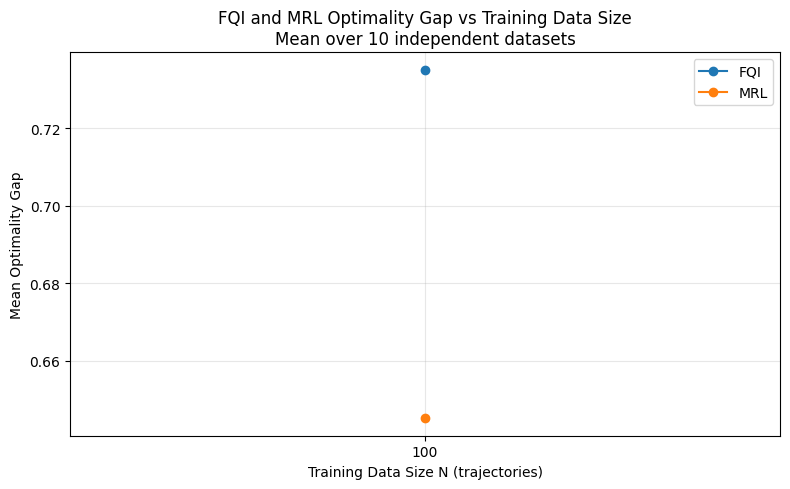

In [15]:
# =========================================================
# Summarize optimality gap over all independent trials.
# Compute the mean and standard deviation of the optimality
# gap for each training data size N.
# =========================================================
fqi_mean_gaps = np.nanmean(
    fqi_gap_matrix,
    axis=0,
)

mrl_mean_gaps = np.nanmean(
    mrl_gap_matrix,
    axis=0,
)

fqi_std_gaps = np.nanstd(
    fqi_gap_matrix,
    axis=0,
    ddof=1,
)

mrl_std_gaps = np.nanstd(
    mrl_gap_matrix,
    axis=0,
    ddof=1,
)

summary_df = pd.DataFrame(
    {
        "N": Ns,
        "FQI_Mean_Gap": fqi_mean_gaps,
        "FQI_Std_Gap": fqi_std_gaps,
        "MRL_Mean_Gap": mrl_mean_gaps,
        "MRL_Std_Gap": mrl_std_gaps,
    }
)

display(summary_df)

# =========================================================
# Visualize the average performance of FQI and MRL as N increases.
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    Ns,
    fqi_mean_gaps,
    marker="o",
    label="FQI",
)

plt.plot(
    Ns,
    mrl_mean_gaps,
    marker="o",
    label="MRL",
)

plt.xlabel("Training Data Size N (trajectories)")
plt.ylabel("Mean Optimality Gap")
plt.title(
    "FQI and MRL Optimality Gap vs Training Data Size\n"
    f"Mean over {n_repeats} independent datasets"
)

plt.xticks(Ns)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretability

### Cluster Interpretability

In [15]:
m = models[0]

In [16]:
df_cluster = m.df_trained.copy()

feature_names = {
    "FEATURE_0": "Heart Rate",
    "FEATURE_1": "Systolic BP",
    "FEATURE_2": "Oxygen Saturation",
    "FEATURE_3": "Glucose",
    "FEATURE_4": "Antibiotics",
    "FEATURE_5": "Vasopressors",
    "FEATURE_6": "Ventilation",
}

feature_cols = [f"FEATURE_{i}" for i in range(7)]

required_cols = ["CLUSTER", *feature_cols]
missing_cols = [c for c in required_cols if c not in df_cluster.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

# 排除可能存在的无效 cluster label
df_cluster = df_cluster.dropna(
    subset=["CLUSTER", *feature_cols]
).copy()

df_cluster["CLUSTER"] = df_cluster["CLUSTER"].astype(int)

for col in feature_cols:
    df_cluster[col] = pd.to_numeric(
        df_cluster[col],
        errors="raise",
    )

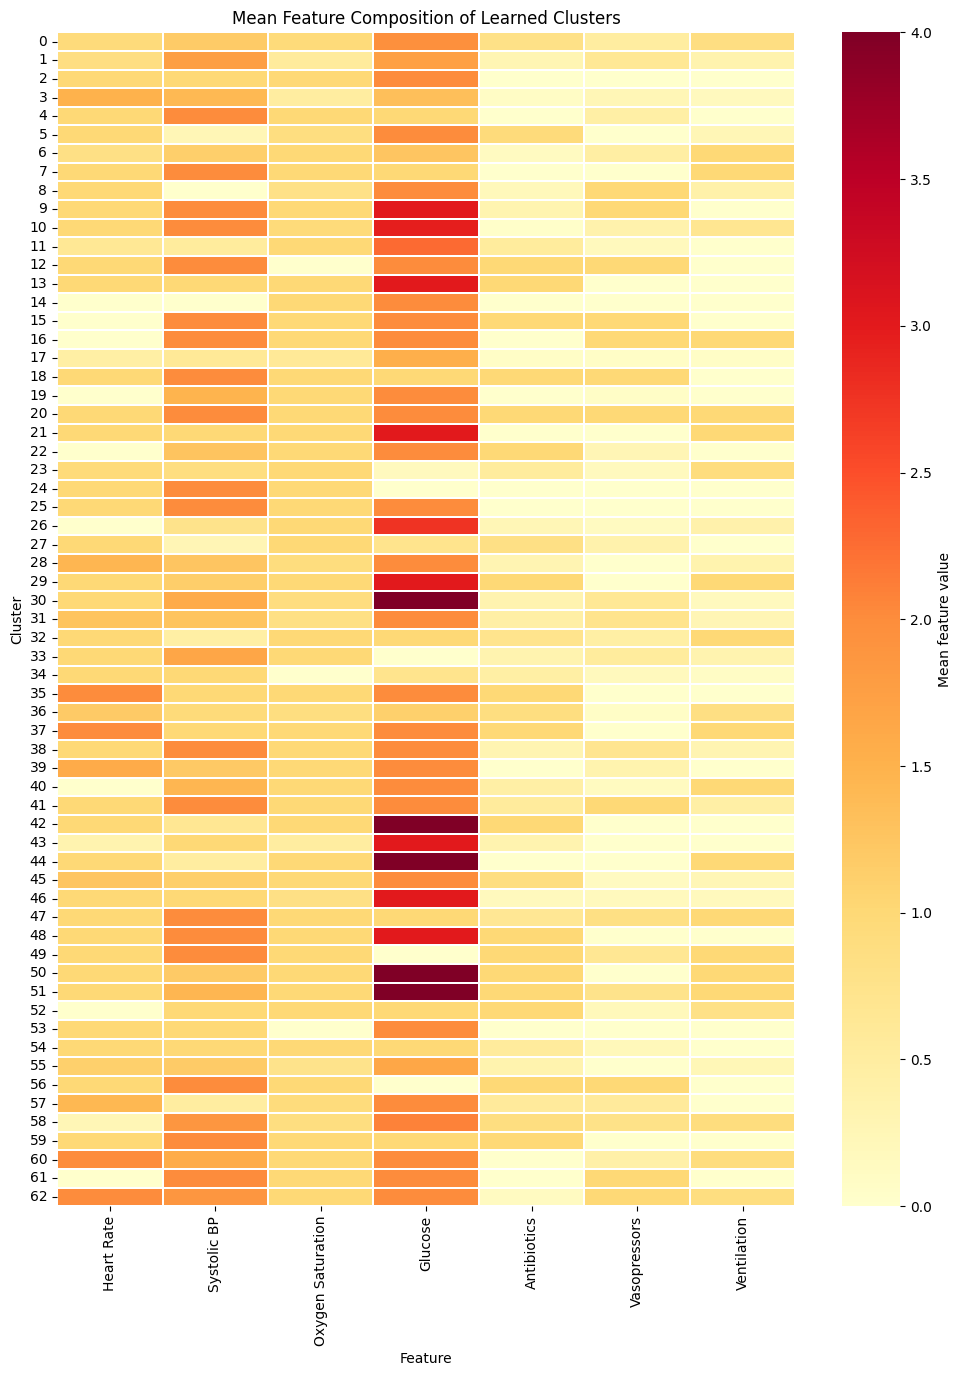

In [17]:
import seaborn as sns

cluster_feature_mean = (
    df_cluster
    .groupby("CLUSTER")[feature_cols]
    .mean()
    .sort_index()
)

cluster_feature_mean_named = (
    cluster_feature_mean
    .rename(columns=feature_names)
)

plt.figure(
    figsize=(
        10,
        max(6, 0.22 * len(cluster_feature_mean_named))
    )
)

sns.heatmap(
    cluster_feature_mean_named,
    cmap="YlOrRd",
    linewidths=0.15,
    linecolor="white",
    cbar_kws={
        "label": "Mean feature value",
    },
)

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.title("Mean Feature Composition of Learned Clusters")
plt.tight_layout()
plt.show()

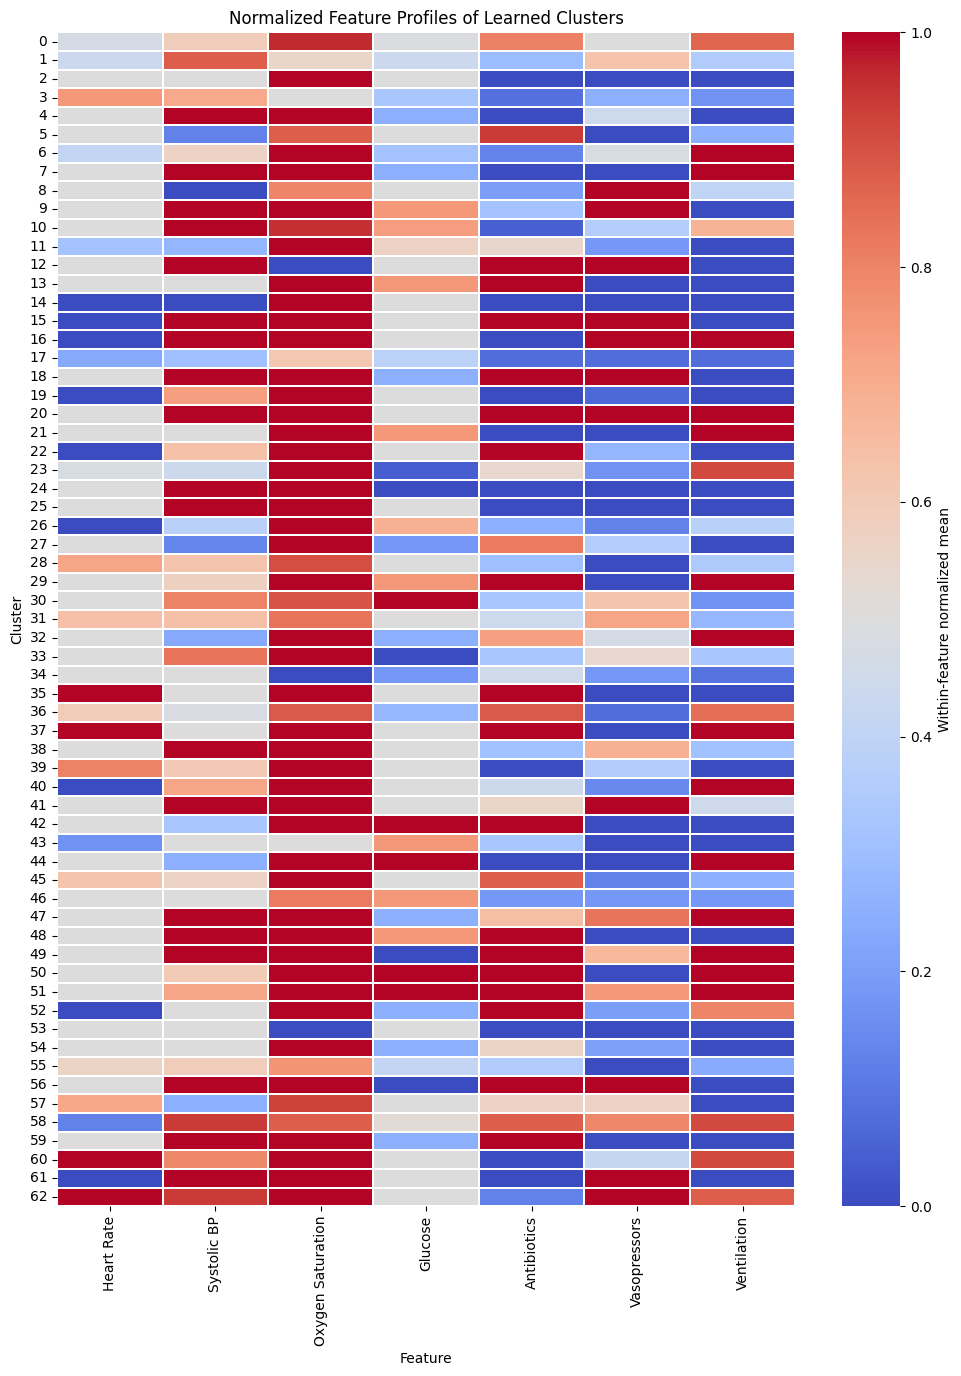

In [17]:
column_min = cluster_feature_mean.min(axis=0)
column_max = cluster_feature_mean.max(axis=0)

column_range = (
    column_max - column_min
).replace(0, 1)

cluster_feature_mean_scaled = (
    cluster_feature_mean - column_min
) / column_range

cluster_feature_mean_scaled_named = (
    cluster_feature_mean_scaled
    .rename(columns=feature_names)
)

plt.figure(
    figsize=(
        10,
        max(6, 0.22 * len(cluster_feature_mean_scaled_named))
    )
)

sns.heatmap(
    cluster_feature_mean_scaled_named,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.15,
    linecolor="white",
    cbar_kws={
        "label": "Within-feature normalized mean",
    },
)

plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.title(
    "Normalized Feature Profiles of Learned Clusters"
)

plt.tight_layout()
plt.show()

In [18]:
# 每个 cluster 的样本数
cluster_sizes = (
    df_cluster
    .groupby("CLUSTER")
    .size()
)

cluster_weights = (
    cluster_sizes / cluster_sizes.sum()
)

# 每个 cluster、每个 feature 的样本方差
cluster_feature_variance = (
    df_cluster
    .groupby("CLUSTER")[feature_cols]
    .var(ddof=1)
    .fillna(0.0)
)

# 总体方差：没有 cluster information 的 baseline
global_feature_variance = (
    df_cluster[feature_cols]
    .var(ddof=1)
)

# 按 cluster size 加权的 within-cluster variance
weighted_within_variance = (
    cluster_feature_variance
    .mul(cluster_weights, axis=0)
    .sum(axis=0)
)

# 防止总体方差为 0
variance_ratio = (
    weighted_within_variance
    .div(global_feature_variance.replace(0, np.nan))
)

variance_reduction = 1 - variance_ratio

variance_summary = pd.DataFrame({
    "Global variance": global_feature_variance,
    "Weighted within-cluster variance": weighted_within_variance,
    "Within/global variance ratio": variance_ratio,
    "Variance reduction": variance_reduction,
})

variance_summary.index = [
    feature_names[col]
    for col in variance_summary.index
]

display(variance_summary.round(4))

,Global variance,Weighted within-cluster variance,Within/global variance ratio,Variance reduction
Heart Rate,0.3096,0.1193,0.3854,0.6146
Systolic BP,0.4246,0.1844,0.4342,0.5658
Oxygen Saturation,0.0846,0.0510,0.6023,0.3977
Glucose,1.0346,0.2320,0.2242,0.7758
Antibiotics,0.2482,0.1394,0.5616,0.4384
Vasopressors,0.2492,0.1333,0.5349,0.4651
Ventilation,0.2469,0.0932,0.3774,0.6226


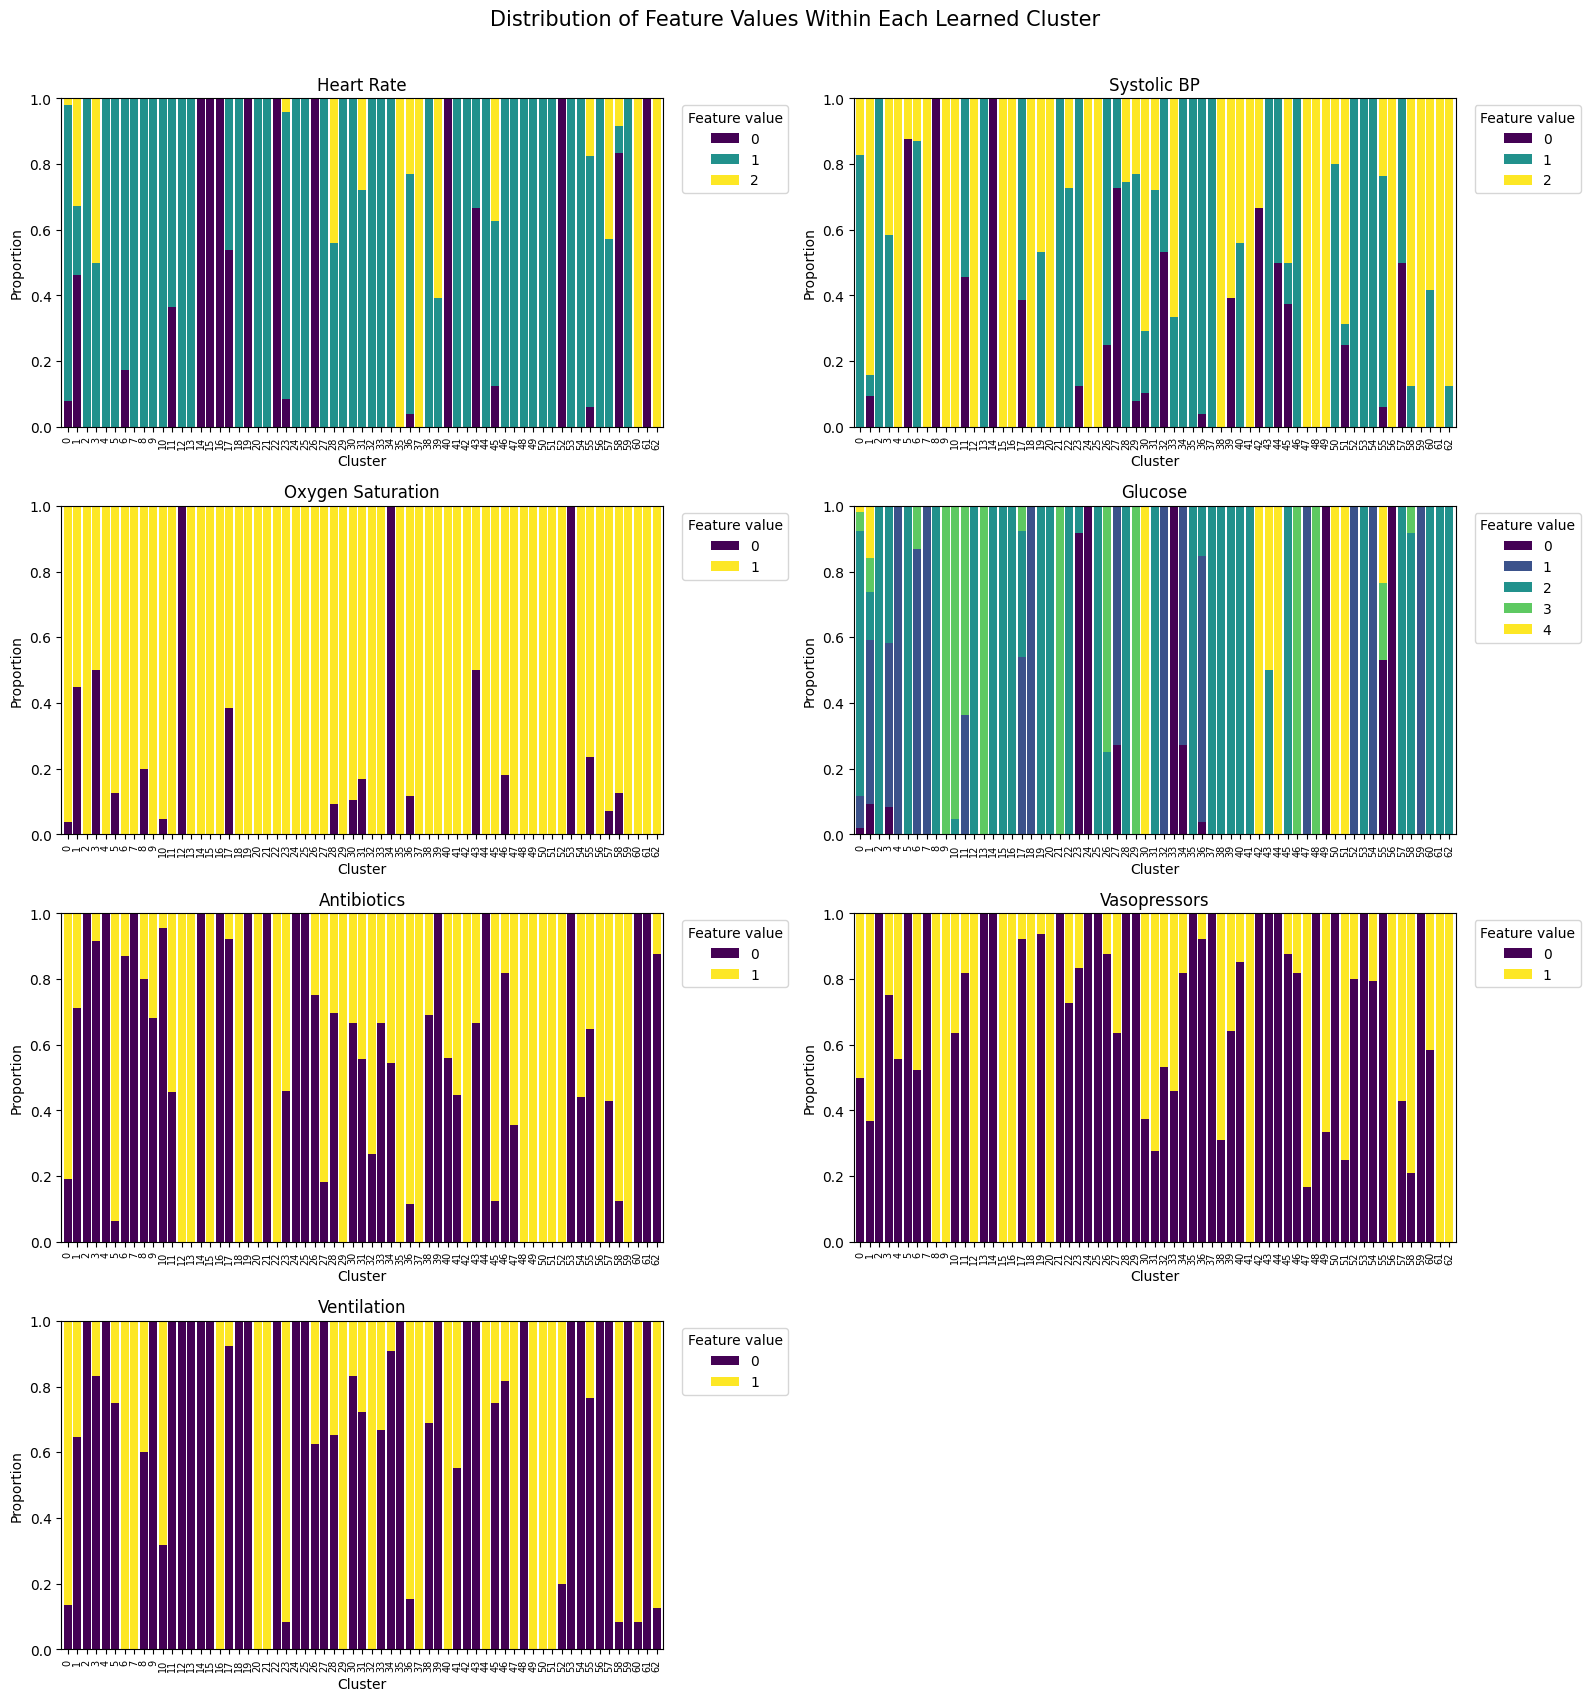

In [19]:
def plot_feature_value_composition(
    df,
    feature_cols,
    feature_names,
    cluster_col="CLUSTER",
    ncols=2,
):
    n_features = len(feature_cols)
    nrows = int(
        np.ceil(n_features / ncols)
    )

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4.2 * nrows),
        squeeze=False,
    )

    axes = axes.flatten()

    for ax, feature in zip(axes, feature_cols):

        composition = (
            df
            .groupby(cluster_col)[feature]
            .value_counts(normalize=True)
            .unstack(fill_value=0)
            .sort_index()
        )

        # 数值状态按大小排列
        composition = composition.reindex(
            sorted(composition.columns),
            axis=1,
        )

        composition.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            width=0.85,
            colormap="viridis",
        )

        ax.set_title(
            feature_names.get(feature, feature)
        )
        ax.set_xlabel("Cluster")
        ax.set_ylabel("Proportion")
        ax.set_ylim(0, 1)

        ax.legend(
            title="Feature value",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
        )

        ax.tick_params(
            axis="x",
            labelrotation=90,
            labelsize=7,
        )

    # 删除多余 subplot
    for ax in axes[n_features:]:
        ax.remove()

    fig.suptitle(
        "Distribution of Feature Values Within Each Learned Cluster",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()


plot_feature_value_composition(
    df=df_cluster,
    feature_cols=feature_cols,
    feature_names=feature_names,
)

In [20]:
from sklearn.metrics import normalized_mutual_info_score

feature_nmi = {}

for feature in feature_cols:
    feature_nmi[feature_names[feature]] = (
        normalized_mutual_info_score(
            df_cluster["CLUSTER"],
            df_cluster[feature],
        )
    )

feature_nmi = pd.Series(
    feature_nmi,
    name="NMI with cluster"
).sort_values(ascending=False)

display(feature_nmi)

,NMI with cluster
Glucose,0.434533
Heart Rate,0.251001
Systolic BP,0.235886
Ventilation,0.183902
Vasopressors,0.138772
Antibiotics,0.130222
Oxygen Saturation,0.075126


In [21]:
def mean_variance_reduction(df, feature_cols):
    global_var = df[feature_cols].var(ddof=1)

    sizes = df.groupby("CLUSTER").size()
    weights = sizes / sizes.sum()

    within_var = (
        df.groupby("CLUSTER")[feature_cols]
        .var(ddof=1)
        .fillna(0)
        .mul(weights, axis=0)
        .sum(axis=0)
    )

    return 1 - within_var / global_var.replace(0, np.nan)


observed_vr = mean_variance_reduction(
    df_cluster,
    feature_cols,
)

rng = np.random.default_rng(0)
n_perm = 500
permuted_vr = []

labels = df_cluster["CLUSTER"].to_numpy()

for _ in range(n_perm):
    df_perm = df_cluster.copy()
    df_perm["CLUSTER"] = rng.permutation(labels)

    permuted_vr.append(
        mean_variance_reduction(
            df_perm,
            feature_cols,
        ).to_numpy()
    )

permuted_vr = np.asarray(permuted_vr)

baseline_mean = pd.Series(
    permuted_vr.mean(axis=0),
    index=feature_cols,
)

baseline_q95 = pd.Series(
    np.quantile(permuted_vr, 0.95, axis=0),
    index=feature_cols,
)

comparison = pd.DataFrame({
    "Observed VR": observed_vr,
    "Random mean": baseline_mean,
    "Random 95% quantile": baseline_q95,
})

comparison.index = [
    feature_names[c] for c in comparison.index
]

display(comparison)

,Observed VR,Random mean,Random 95% quantile
Heart Rate,0.614563,-0.000211,0.018793
Systolic BP,0.565778,0.001380,0.020509
Oxygen Saturation,0.397691,0.000952,0.020509
Glucose,0.775796,0.001114,0.020066
Antibiotics,0.438438,-0.000011,0.017543
Vasopressors,0.465100,0.000086,0.020164
Ventilation,0.622574,0.001119,0.019286


### Policy Interpretability

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sepsisSimDiabetes.State import State


def plot_true_vs_mrl_policy_map(
    m,
    true_pi,
    fixed_values,
    x_col,
    y_col,
    feature_names=None,
    figsize=(12, 5),
):
    """
    Plot True Policy vs MRL Policy for any two categorical features.

    x_col, y_col:
        Two features to vary.

    fixed_values:
        Values of all remaining 5 features.
    """

    feature_cols = [f"FEATURE_{i}" for i in range(7)]

    if feature_names is None:
        feature_names = {col: col for col in feature_cols}

    # Complete category sets defined by the simulator
    category_values = {
        "FEATURE_0": np.array([0, 1, 2]),
        "FEATURE_1": np.array([0, 1, 2]),
        "FEATURE_2": np.array([0, 1]),
        "FEATURE_3": np.array([0, 1, 2, 3, 4]),
        "FEATURE_4": np.array([0, 1]),
        "FEATURE_5": np.array([0, 1]),
        "FEATURE_6": np.array([0, 1]),
    }

    x_values = category_values[x_col]
    y_values = category_values[y_col]

    # ============================================================
    # 1. Build shared 7D state grid
    # ============================================================

    rows = []

    for y in y_values:
        for x in x_values:

            row = {}

            for col in feature_cols:

                if col == x_col:
                    row[col] = x

                elif col == y_col:
                    row[col] = y

                else:
                    row[col] = fixed_values[col]

            rows.append(row)

    grid = pd.DataFrame(
        rows,
        columns=feature_cols
    )

    # ============================================================
    # 2. True policy
    # ============================================================

    true_actions = []

    for _, row in grid.iterrows():

        state = State(
            state_categs=[
                int(row["FEATURE_0"]),
                int(row["FEATURE_1"]),
                int(row["FEATURE_2"]),
                int(row["FEATURE_3"]),
                int(row["FEATURE_4"]),
                int(row["FEATURE_5"]),
                int(row["FEATURE_6"]),
            ],
            diabetic_idx=0,
        )

        state_idx = state.get_state_idx(
            idx_type="obs"
        )

        true_actions.append(
            int(true_pi[state_idx])
        )

    true_policy = np.array(
        true_actions
    ).reshape(
        len(y_values),
        len(x_values)
    )

    # ============================================================
    # 3. MRL policy
    # ============================================================

    predicted_clusters = m.m.predict(
        grid[feature_cols]
    )

    mrl_actions = np.array([
        int(m.pi[int(cluster)])
        for cluster in predicted_clusters
    ])

    mrl_policy = mrl_actions.reshape(
        len(y_values),
        len(x_values)
    )

    # ============================================================
    # 4. Colours
    # ============================================================

    cmap = ListedColormap(
        plt.cm.tab10.colors[:8]
    )

    norm = BoundaryNorm(
        np.arange(-0.5, 8.5, 1),
        cmap.N
    )

    # ============================================================
    # 5. Plot
    # ============================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=figsize,
        constrained_layout=True
    )

    im_true = axes[0].imshow(
        true_policy,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        extent=[
            x_values.min() - 0.5,
            x_values.max() + 0.5,
            y_values.min() - 0.5,
            y_values.max() + 0.5,
        ],
    )

    im_mrl = axes[1].imshow(
        mrl_policy,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm,
        extent=[
            x_values.min() - 0.5,
            x_values.max() + 0.5,
            y_values.min() - 0.5,
            y_values.max() + 0.5,
        ],
    )

    axes[0].set_title("(a) True Optimal Policy")
    axes[1].set_title("(b) MRL Policy")

    for ax in axes:

        ax.set_xlabel(
            feature_names[x_col]
        )

        ax.set_ylabel(
            feature_names[y_col]
        )

        ax.set_xticks(x_values)
        ax.set_yticks(y_values)

    # ============================================================
    # 6. Shared colorbar
    # ============================================================

    cbar = fig.colorbar(
        im_mrl,
        ax=axes,
        ticks=np.arange(8),
        fraction=0.035,
        pad=0.04,
    )

    cbar.set_label("Action")

    # ============================================================
    # 7. Fixed feature description
    # ============================================================

    fixed_features = [
        col for col in feature_cols
        if col not in [x_col, y_col]
    ]

    fixed_text = ", ".join(
        f"{feature_names[col]}={fixed_values[col]}"
        for col in fixed_features
    )

    fig.suptitle(
        f"Policy Interpretability: "
        f"{feature_names[x_col]} × {feature_names[y_col]}\n"
        f"Fixed categorical features: {fixed_text}",
        fontsize=13,
    )

    plt.show()

    # ============================================================
    # 8. Agreement
    # ============================================================

    agreement = (
        true_policy == mrl_policy
    )

    print(
        f"{feature_names[x_col]} × "
        f"{feature_names[y_col]} | "
        f"Agreement = {agreement.mean():.3f} "
        f"({agreement.sum()}/{agreement.size})"
    )

    return true_policy, mrl_policy

In [21]:
from itertools import combinations


feature_names = {
    "FEATURE_0": "Heart Rate",
    "FEATURE_1": "Systolic Blood Pressure",
    "FEATURE_2": "Oxygen Saturation",
    "FEATURE_3": "Glucose",
    "FEATURE_4": "Antibiotics",
    "FEATURE_5": "Vasopressors",
    "FEATURE_6": "Ventilation",
}


# ------------------------------------------------------------
# Baseline values
#
# 注意：
# 每次画某两个feature时，这个dict里对应的两个值不会被使用。
# 其余5个feature使用这里的值。
# ------------------------------------------------------------

fixed_values = {
    "FEATURE_0": 1,
    "FEATURE_1": 1,
    "FEATURE_2": 1,
    "FEATURE_3": 2,
    "FEATURE_4": 0,
    "FEATURE_5": 0,
    "FEATURE_6": 0,
}


# ------------------------------------------------------------
# FEATURE_0 ~ FEATURE_3 的所有两两组合
# ------------------------------------------------------------

features_to_compare = [
    "FEATURE_0",
    "FEATURE_1",
    "FEATURE_2",
    "FEATURE_3",
]

pairs = list(
    combinations(features_to_compare, 2)
)

print(pairs)

[('FEATURE_0', 'FEATURE_1'), ('FEATURE_0', 'FEATURE_2'), ('FEATURE_0', 'FEATURE_3'), ('FEATURE_1', 'FEATURE_2'), ('FEATURE_1', 'FEATURE_3'), ('FEATURE_2', 'FEATURE_3')]



FEATURE_0 × FEATURE_1


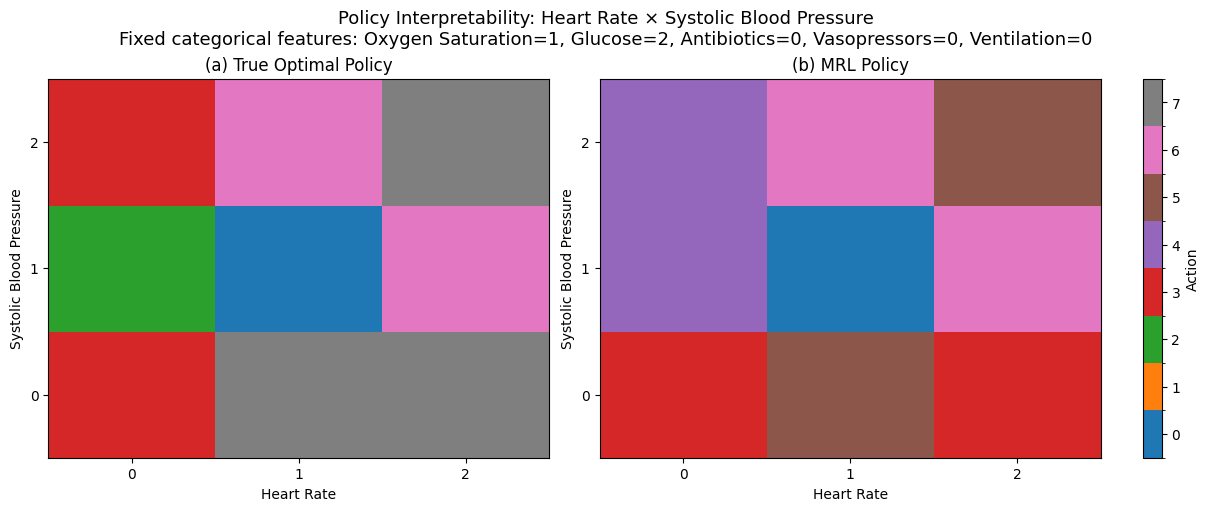

Heart Rate × Systolic Blood Pressure | Agreement = 0.444 (4/9)

FEATURE_0 × FEATURE_2


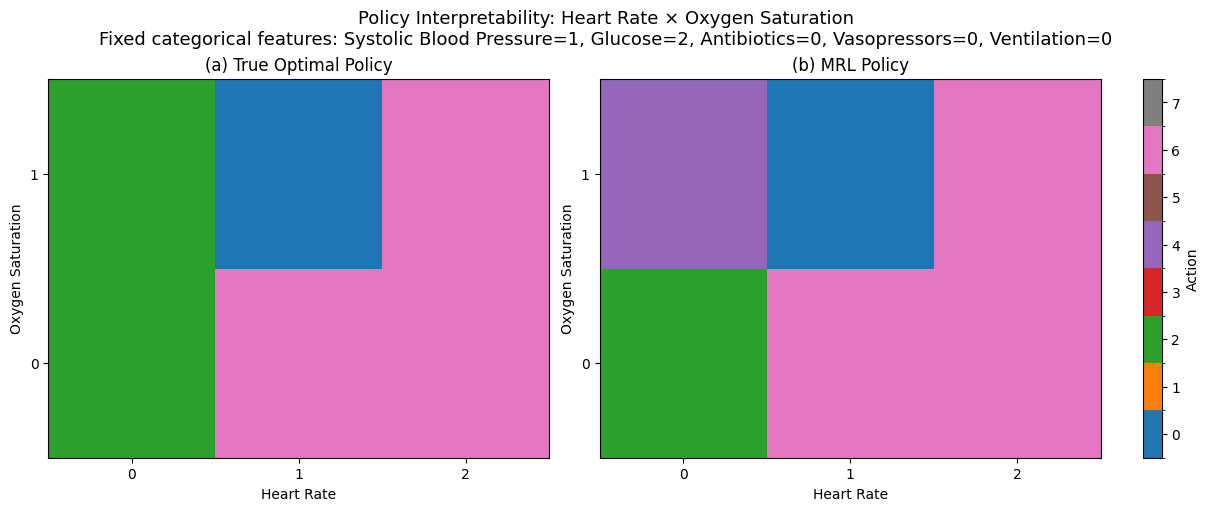

Heart Rate × Oxygen Saturation | Agreement = 0.833 (5/6)

FEATURE_0 × FEATURE_3


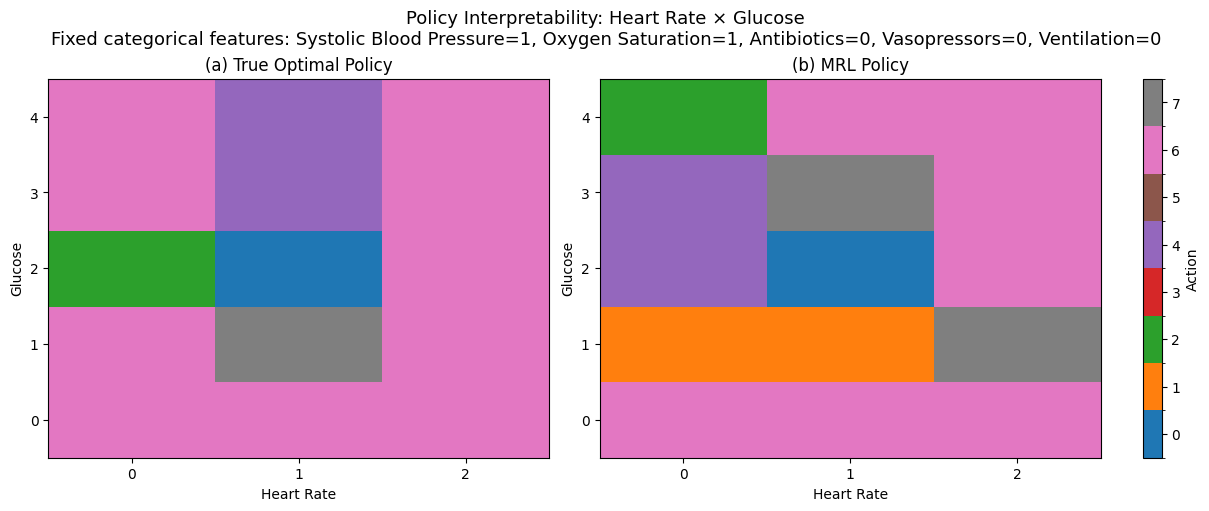

Heart Rate × Glucose | Agreement = 0.467 (7/15)

FEATURE_1 × FEATURE_2


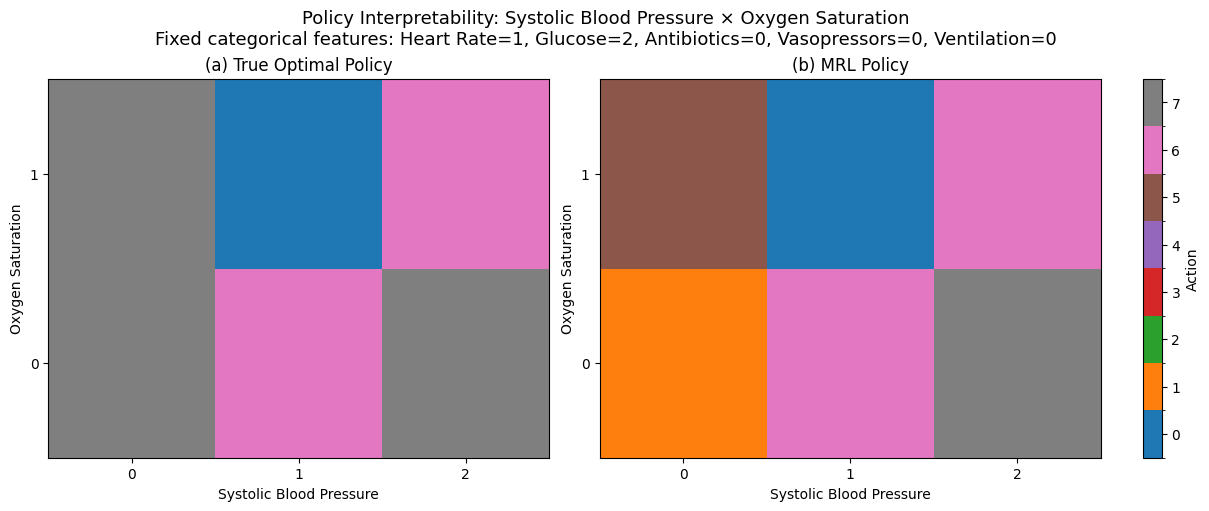

Systolic Blood Pressure × Oxygen Saturation | Agreement = 0.667 (4/6)

FEATURE_1 × FEATURE_3


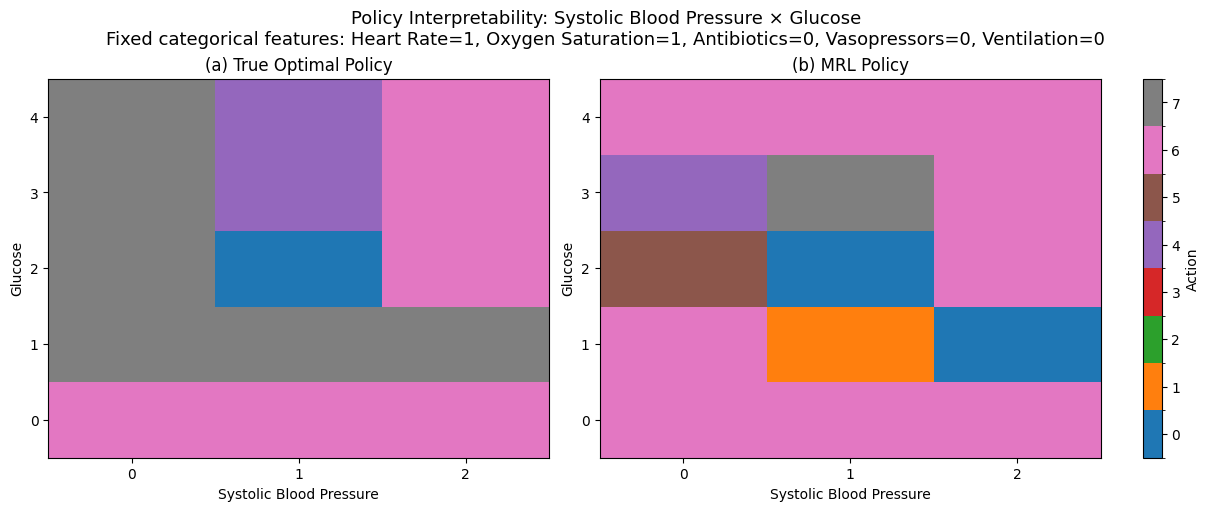

Systolic Blood Pressure × Glucose | Agreement = 0.467 (7/15)

FEATURE_2 × FEATURE_3


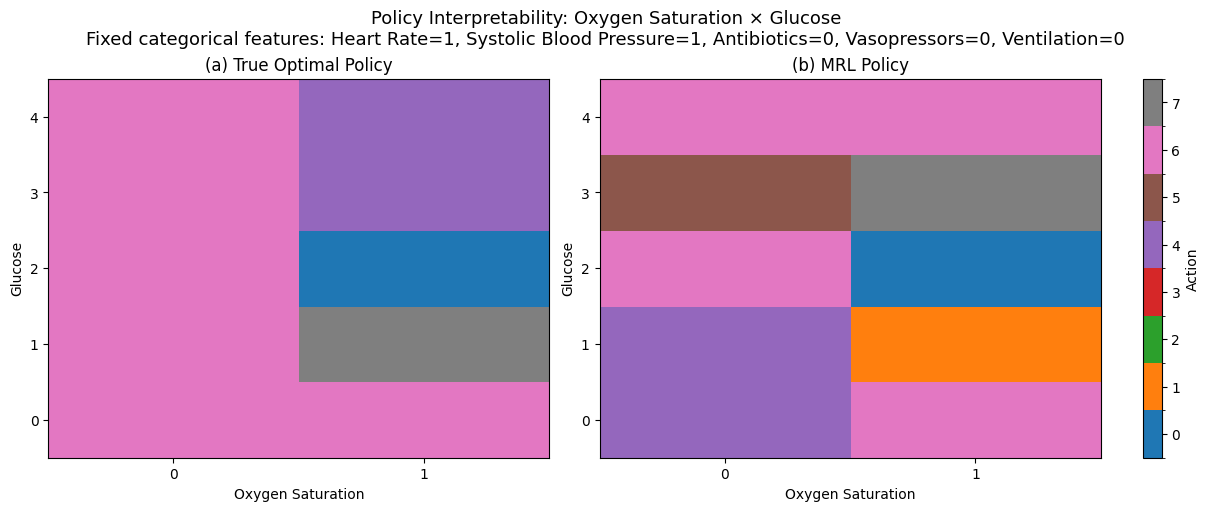

Oxygen Saturation × Glucose | Agreement = 0.400 (4/10)


In [22]:
policy_results = {}

for x_col, y_col in pairs:

    print(
        "\n",
        "=" * 70,
        f"\n{x_col} × {y_col}"
    )

    true_policy, mrl_policy = plot_true_vs_mrl_policy_map(
        m=models[0],
        true_pi=true_pi,
        fixed_values=fixed_values,
        x_col=x_col,
        y_col=y_col,
        feature_names=feature_names,
    )

    policy_results[(x_col, y_col)] = {
        "true": true_policy,
        "mrl": mrl_policy,
    }

### Latent Diabetes Recovery


=== Latent-state recovery: trial-level results ===


,REPEAT,N,N_CLUSTERS,N_OBSERVATIONS,MEAN_CLUSTER_PURITY,WEIGHTED_PURITY,NMI
0,0,100,61,1034,0.873174,0.880077,0.103756
1,1,100,55,990,0.876477,0.863636,0.085766
2,2,100,51,1011,0.911568,0.912957,0.049773
3,3,100,50,974,0.817778,0.830595,0.079682
4,4,100,45,960,0.913397,0.901042,0.066266
5,5,100,61,949,0.905692,0.892518,0.096911
6,6,100,53,978,0.901857,0.894683,0.091208
7,7,100,52,1072,0.915090,0.916978,0.041228
8,8,100,56,892,0.899789,0.894619,0.140746
9,9,100,63,1094,0.879305,0.893967,0.067176



=== Latent-state recovery: mean ± SD over 10 trials ===


,Mean,Std
Mean cluster purity,0.889413,0.029661
Weighted purity,0.888107,0.025229
NMI,0.082251,0.028711
Number of clusters,54.700000,5.677441



=== Cluster diabetes composition: Repeat 0 ===


,CLUSTER,NON_DIABETIC_COUNT,DIABETIC_COUNT,TOTAL,NON_DIABETIC_PROP,DIABETIC_PROP,PURITY
0,0,61,5,66,0.924242,0.075758,0.924242
1,1,56,22,78,0.717949,0.282051,0.717949
2,2,1,1,2,0.500000,0.500000,0.500000
3,3,27,0,27,1.000000,0.000000,1.000000
4,4,6,4,10,0.600000,0.400000,0.600000
...,...,...,...,...,...,...,...
56,56,15,0,15,1.000000,0.000000,1.000000
57,57,4,0,4,1.000000,0.000000,1.000000
58,58,6,3,9,0.666667,0.333333,0.666667
59,59,5,1,6,0.833333,0.166667,0.833333


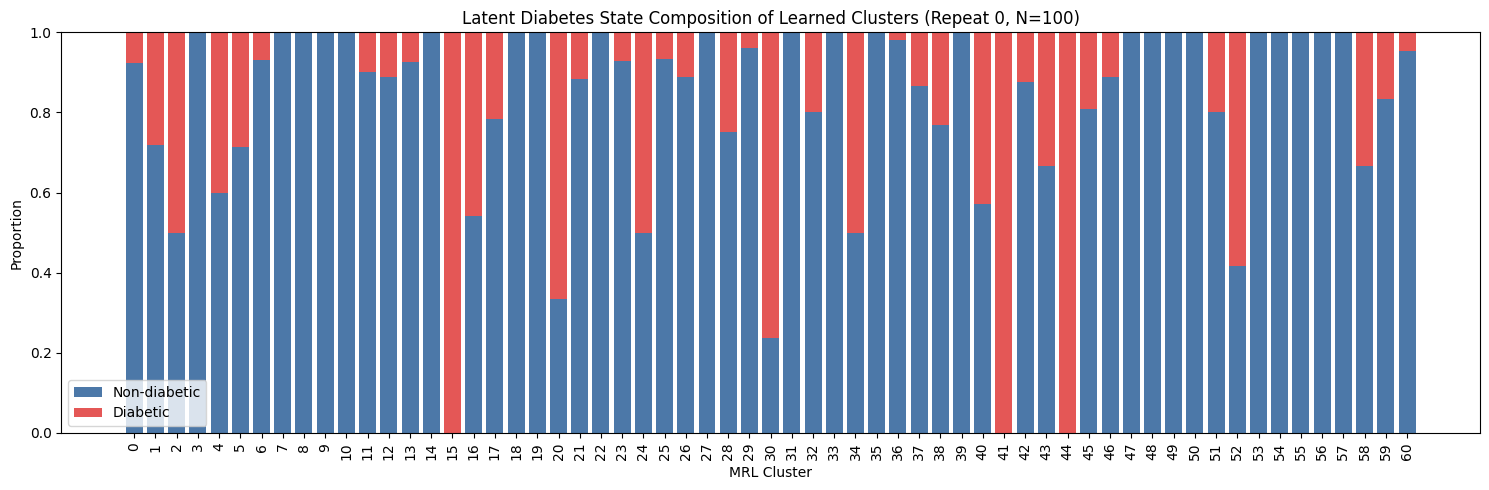

In [16]:
# ============================================================
# 1. Latent diabetes recovery evaluation over all 10 trials
# ============================================================

trial_results = []
cluster_composition_all = []
df_eval_all = {}

for repeat_idx in range(n_repeats):

    # --------------------------------------------------------
    # Cluster assignment from the largest-N model
    # --------------------------------------------------------
    df_eval = maxN_cluster_maps[repeat_idx].copy()
    diabetes_map = diabetes_maps[repeat_idx]

    # Map trajectory ID -> true latent diabetes state
    df_eval["DIABETES"] = (
        df_eval["ID"]
        .astype(int)
        .map(diabetes_map)
    )

    # Safety checks
    if df_eval["DIABETES"].isna().any():
        missing_ids = (
            df_eval.loc[
                df_eval["DIABETES"].isna(),
                "ID"
            ]
            .unique()
        )

        raise ValueError(
            f"Repeat {repeat_idx}: "
            f"missing diabetes labels for IDs "
            f"{missing_ids[:20]}"
        )

    df_eval["DIABETES"] = (df_eval["DIABETES"].astype(int))
    df_eval["CLUSTER"] = (df_eval["CLUSTER"].astype(int))
    df_eval_all[repeat_idx] = df_eval.copy()

    # ========================================================
    # 2. Diabetes composition of each cluster
    # ========================================================

    counts = pd.crosstab(
        df_eval["CLUSTER"],
        df_eval["DIABETES"],
    )

    # Guarantee both latent classes exist as columns
    counts = counts.reindex(
        columns=[0, 1],
        fill_value=0,
    )

    counts.columns = [
        "NON_DIABETIC_COUNT",
        "DIABETIC_COUNT",
    ]

    counts["TOTAL"] = counts.sum(axis=1)

    counts["NON_DIABETIC_PROP"] = (
        counts["NON_DIABETIC_COUNT"]
        / counts["TOTAL"]
    )

    counts["DIABETIC_PROP"] = (
        counts["DIABETIC_COUNT"]
        / counts["TOTAL"]
    )

    # ========================================================
    # 3. Cluster purity
    # ========================================================

    counts["PURITY"] = (
        counts[
            [
                "NON_DIABETIC_COUNT",
                "DIABETIC_COUNT",
            ]
        ]
        .max(axis=1)
        / counts["TOTAL"]
    )

    counts = counts.reset_index()
    counts["REPEAT"] = repeat_idx

    cluster_composition_all.append(
        counts.copy()
    )

    # --------------------------------------------------------
    # Mean purity across clusters
    # Each cluster receives equal weight
    # --------------------------------------------------------
    mean_cluster_purity = (
        counts["PURITY"].mean()
    )

    # --------------------------------------------------------
    # Weighted purity
    # Each observation receives equal weight
    # --------------------------------------------------------
    weighted_purity = (
        (
            counts["PURITY"]
            * counts["TOTAL"]
        ).sum()
        / counts["TOTAL"].sum()
    )

    # ========================================================
    # 4. Normalized Mutual Information
    # ========================================================

    nmi = normalized_mutual_info_score(
        df_eval["DIABETES"],
        df_eval["CLUSTER"],
    )

    # ========================================================
    # 5. Save trial-level metrics
    # ========================================================

    trial_results.append(
        {
            "REPEAT": repeat_idx,
            "N": N_max,
            "N_CLUSTERS": (
                df_eval["CLUSTER"].nunique()
            ),
            "N_OBSERVATIONS": len(df_eval),
            "MEAN_CLUSTER_PURITY": (
                mean_cluster_purity
            ),
            "WEIGHTED_PURITY": (
                weighted_purity
            ),
            "NMI": nmi,
        }
    )


# ============================================================
# 6. Combine all trial results
# ============================================================

trial_results = pd.DataFrame(trial_results)

cluster_composition_all = pd.concat(
    cluster_composition_all,
    ignore_index=True,
)


# ============================================================
# 7. Summary over 10 independent trials
# ============================================================

summary = pd.DataFrame(
    {
        "Mean": [
            trial_results[
                "MEAN_CLUSTER_PURITY"
            ].mean(),

            trial_results[
                "WEIGHTED_PURITY"
            ].mean(),

            trial_results[
                "NMI"
            ].mean(),

            trial_results[
                "N_CLUSTERS"
            ].mean(),
        ],

        "Std": [
            trial_results[
                "MEAN_CLUSTER_PURITY"
            ].std(ddof=1),

            trial_results[
                "WEIGHTED_PURITY"
            ].std(ddof=1),

            trial_results[
                "NMI"
            ].std(ddof=1),

            trial_results[
                "N_CLUSTERS"
            ].std(ddof=1),
        ],
    },

    index=[
        "Mean cluster purity",
        "Weighted purity",
        "NMI",
        "Number of clusters",
    ],
)


print(
    "\n=== Latent-state recovery: "
    "trial-level results ==="
)

display(trial_results)


print(
    "\n=== Latent-state recovery: "
    "mean ± SD over 10 trials ==="
)

display(summary)


# ============================================================
# 8. Representative example: Repeat 0 only
# ============================================================

representative_repeat = 0

comp_example = (
    cluster_composition_all[
        cluster_composition_all["REPEAT"]
        == representative_repeat
    ]
    .sort_values("CLUSTER")
    .copy()
)


print(
    f"\n=== Cluster diabetes composition: "
    f"Repeat {representative_repeat} ==="
)

display(
    comp_example[
        [
            "CLUSTER",
            "NON_DIABETIC_COUNT",
            "DIABETIC_COUNT",
            "TOTAL",
            "NON_DIABETIC_PROP",
            "DIABETIC_PROP",
            "PURITY",
        ]
    ]
)


# ============================================================
# 9. Plot latent diabetes composition for Repeat 0
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 5)
)

x = np.arange(
    len(comp_example)
)

ax.bar(
    x,
    comp_example[
        "NON_DIABETIC_PROP"
    ],
    label="Non-diabetic",
    color="#4C78A8",
)

ax.bar(
    x,
    comp_example[
        "DIABETIC_PROP"
    ],
    bottom=comp_example[
        "NON_DIABETIC_PROP"
    ],
    label="Diabetic",
    color="#E45756",
)

ax.set_xticks(x)

ax.set_xticklabels(
    comp_example["CLUSTER"],
    rotation=90,
)

ax.set_ylim(
    0,
    1,
)

ax.set_xlabel(
    "MRL Cluster"
)

ax.set_ylabel(
    "Proportion"
)

ax.set_title(
    "Latent Diabetes State Composition "
    f"of Learned Clusters "
    f"(Repeat {representative_repeat}, "
    f"N={N_max})"
)

ax.legend()

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
from sklearn.metrics import (
    mutual_info_score,
    normalized_mutual_info_score,
)

# ============================================================
# Largest-N MRL model from the last trial
# ============================================================

m = models[-1]

df_eval = m.df_trained.copy()

# ============================================================
# Add latent diabetes labels
# diabetes_map: {trajectory ID -> latent diabetes}
# ============================================================

df_eval["DIABETES"] = (
    df_eval["ID"]
    .astype(int)
    .map(diabetes_map)
)

if df_eval["DIABETES"].isna().any():
    raise ValueError("Some trajectory IDs do not have diabetes labels.")

df_eval["DIABETES"] = df_eval["DIABETES"].astype(int)

# ============================================================
# Feature names
# ============================================================

feature_cols = [
    "FEATURE_0",
    "FEATURE_1",
    "FEATURE_2",
    "FEATURE_3",
    "FEATURE_4",
    "FEATURE_5",
    "FEATURE_6",
]

feature_names = {
    "FEATURE_0": "Heart Rate",
    "FEATURE_1": "Systolic BP",
    "FEATURE_2": "Oxygen Saturation",
    "FEATURE_3": "Glucose",
    "FEATURE_4": "Antibiotics",
    "FEATURE_5": "Vasopressors",
    "FEATURE_6": "Ventilation",
}

# ============================================================
# Mutual information of each feature with latent diabetes
# ============================================================

results = []

for feat in feature_cols:

    mi = mutual_info_score(
        df_eval["DIABETES"],
        df_eval[feat],
    )

    nmi = normalized_mutual_info_score(
        df_eval["DIABETES"],
        df_eval[feat],
    )

    results.append(
        {
            "Feature": feature_names[feat],
            "MI": mi,
            "NMI": nmi,
        }
    )

# ============================================================
# Cluster <-> diabetes
# ============================================================

cluster_mi = mutual_info_score(
    df_eval["DIABETES"],
    df_eval["CLUSTER"],
)

cluster_nmi = normalized_mutual_info_score(
    df_eval["DIABETES"],
    df_eval["CLUSTER"],
)

results.append(
    {
        "Feature": "MRL Cluster",
        "MI": cluster_mi,
        "NMI": cluster_nmi,
    }
)

results = (
    pd.DataFrame(results)
    .sort_values("NMI", ascending=False)
    .reset_index(drop=True)
)

print("Mutual information with latent diabetes:")
display(results)

Mutual information with latent diabetes:


,Feature,MI,NMI
0,Glucose,0.145921,0.164588
1,MRL Cluster,0.142954,0.067176
2,Heart Rate,0.013340,0.021459
3,Systolic BP,0.002127,0.003220
4,Vasopressors,0.000084,0.000152
5,Ventilation,0.000029,0.000053
6,Oxygen Saturation,0.000005,0.000015
7,Antibiotics,0.000004,0.000007


In [18]:
pd.crosstab(
    df_eval["FEATURE_3"],
    df_eval["DIABETES"],
    normalize="index"
)

DIABETES,0,1
FEATURE_3,,
0,0.958333,0.041667
1,0.978339,0.021661
2,0.943580,0.056420
3,0.558559,0.441441
4,0.281250,0.718750


# Inspect Code

In [ ]:
import mrl.evaluation as evaluation
import importlib
import inspect

importlib.reload(evaluation)

print(inspect.getsource(evaluation.value_diff))

def value_diff(
    models,
    baseline_pi,
    num_states,
    num_iters,
    max_num_steps,
    idx_type="obs",
    diabetic_idx=0,
    alpha=0.2,  
    beta=0.8,  
    min_action_obs=-1, 
    min_action_purity=0.7,  
    prob="max",  
    gamma=1.0,  
    epsilon=10 ** (-8),
    p=False,
    p_diabetes=0.2,
    use_median=False,
    use_tqdm=False,
):
    assert idx_type in ["obs", "proj_obs", "full"]

    policy_idx_type = idx_type
    output_state_idx_type = idx_type
    num_actions = Action.NUM_ACTIONS_TOTAL

    baseline_policy_array = deterministic_pi_to_prob_array(
        pi=baseline_pi,
        num_actions=num_actions,
    )

    baseline_value, baseline_returns = estimate_policy_value(
        policy_array=baseline_policy_array,
        num_iters=num_iters,
        max_num_steps=max_num_steps,
        gamma=gamma,
        policy_idx_type=policy_idx_type,
        output_state_idx_type=output_state_idx_type,
        p_diabetes=p_diabetes,
        use_tqdm=use_tqdm,
        t